# Topics to include:-

**Bias-Variance Tradeoff**

**Feature Selection**

**Cross-Validation**

In [ ]:
# Cell 1: Initialization and Setup

# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown

# Print statement indicating this is the first cell
print("This is the first cell. Initialization and setup are done below:")

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Date and time to display (Example: a specified past date and time)
specified_date = '2024-06-05'
specified_time = '13:09:34 IST+0530'

# Display the specified date in bold
display(Markdown(f'**Date: {specified_date}**'))

# Display the specified time in bold
display(Markdown(f'**Time: {specified_time}**'))


This is the first cell. Initialization and setup are done below:


**Date: 2024-06-05**

**Time: 13:09:34 IST+0530**


> We will undestand how to deal with the problem of curse of dimesnioanlity using PCA and will also see how to implement principal component analysis using python.


**Data Set**: We will make use of vehicle-2.csv data set
The data contains features extracted from the silhouette of vehicles in
different angles. Four Corgie & model vehicles were used for the
experiment: a double decker bus, Cheverolet van, Saab 9000 and an
Opel Manta 400 cars. This particular combination of vehicles was
chosen with the expectation that the bus, van and either one of the cars
would be readily distinguishable, but it would be more difficult to
distinguish between the cars.

**Objective:**

The purpose is to classify a given silhouette as one of three types of
vehicle, using a set of features extracted from the silhouette. The vehicle
may be viewed from one of many different angles.
How We Will Meet Our Objective?
We will Apply dimensionality reduction technique - PCA and train a model using the reduced set of principal components (Attributes/dimension). Then we will build Support Vector Classifier on raw data and also on PCA components to see how the model perform on the reduced set of dimension. We will also print the confusion matrix for both the scenario and see how our model has performed in classifying various vehicle types based on given silhouette of vehicles.

**Let's Go Hands-On:**

In [ ]:
#let us start by importing the relevant libraries

%matplotlib inline
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
#import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report,roc_auc_score
from scipy.stats import zscore
from sklearn.model_selection import train_test_split


## Loading Data Set

In [ ]:
vehdf= pd.read_csv("https://raw.githubusercontent.com/9394113857/datasets/edbd62fe2ca2a415499f793004903295d68844d5/vehicle-2.csv")
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
#print(vehdf)


In [ ]:
vehdf.head(200)


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,86,43.0,66.0,130.0,56.0,7,152.0,44.0,19.0,142,177.0,340.0,173.0,81.0,6.0,14.0,181.0,185,bus
196,107,56.0,104.0,231.0,71.0,11,219.0,31.0,25.0,172,226.0,705.0,217.0,71.0,19.0,11.0,189.0,196,car
197,82,44.0,72.0,150.0,64.0,7,154.0,44.0,19.0,144,181.0,350.0,177.0,80.0,0.0,16.0,183.0,187,bus
198,81,46.0,71.0,130.0,56.0,7,153.0,44.0,19.0,149,172.0,342.0,191.0,81.0,3.0,14.0,180.0,186,bus


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
columns = vehdf.columns
#Let's Label Encode our class variable:
print(columns)
vehdf['class'] = le.fit_transform(vehdf['class'])
vehdf.shape

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio', 'class'],
      dtype='object')


(846, 19)

# Performing EDA:

  - Finding Any Missing Value
  - Finding Outliers
  - Understanding attributes using descriptive statistics
  - visualizing attribute distribution using univariate and multivariate analysis
  - Finding attribute correlation and analysing which attribute is more important

## Quick Eyeballing To See if there is any missing values

In [ ]:
vehdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null    float64
 13  scaled_radius_of_gyr

## Quick Insights:
 We can see that :
    - circularity, class, hollow_ratio,max.length_rectangularity, , max.length_aspect_ratio, compactness has no missing values rest all features are having some kind of missing values
    - All attributes are of numerical type
 # Finding The Missing Value:
   Let's find the count of each attribite & treat the missing values   

In [ ]:
from sklearn.impute import SimpleImputer

newdf = vehdf.copy()

X = newdf.iloc[:,0:19] #separting all numercial independent attribute
#y = vehdf.iloc[:,18] #seprarting class attribute.
#imputer = SimpleImputer()
imputer = SimpleImputer(missing_values=np.nan, strategy='median') # removed verbose parameter
#fill missing values with mean column values
transformed_values = imputer.fit_transform(X)
column = X.columns
print(column)
newdf = pd.DataFrame(transformed_values, columns = column )
newdf.describe()

Index(['compactness', 'circularity', 'distance_circularity', 'radius_ratio',
       'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scatter_ratio',
       'elongatedness', 'pr.axis_rectangularity', 'max.length_rectangularity',
       'scaled_variance', 'scaled_variance.1', 'scaled_radius_of_gyration',
       'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1',
       'skewness_about.2', 'hollows_ratio', 'class'],
      dtype='object')


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,93.678487,44.823877,82.100473,168.874704,61.677305,8.567376,168.887707,40.936170,20.580378,147.998818,188.596927,439.314421,174.706856,72.443262,6.361702,12.600473,188.918440,195.632388,0.977541
std,8.234474,6.134272,15.741569,33.401356,7.882188,4.601217,33.197710,7.811882,2.588558,14.515652,31.360427,176.496341,32.546277,7.468734,4.903244,8.930962,6.152247,7.438797,0.702130
min,73.000000,33.000000,40.000000,104.000000,47.000000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.000000,59.000000,0.000000,0.000000,176.000000,181.000000,0.000000
25%,87.000000,40.000000,70.000000,141.000000,57.000000,7.000000,147.000000,33.000000,19.000000,137.000000,167.000000,318.250000,149.000000,67.000000,2.000000,5.000000,184.000000,190.250000,0.000000
50%,93.000000,44.000000,80.000000,167.000000,61.000000,8.000000,157.000000,43.000000,20.000000,146.000000,179.000000,363.500000,173.500000,71.500000,6.000000,11.000000,188.000000,197.000000,1.000000
75%,100.000000,49.000000,98.000000,195.000000,65.000000,10.000000,198.000000,46.000000,23.000000,159.000000,217.000000,586.750000,198.000000,75.000000,9.000000,19.000000,193.000000,201.000000,1.000000
max,119.000000,59.000000,112.000000,333.000000,138.000000,55.000000,265.000000,61.000000,29.000000,188.000000,320.000000,1018.000000,268.000000,135.000000,22.000000,41.000000,206.000000,211.000000,2.000000


In [ ]:
# old cell replaced with new above cell change sonly:-
# from sklearn.impute import SimpleImputer

# newdf = vehdf.copy()

# X = newdf.iloc[:,0:19] #separting all numercial independent attribute
# #y = vehdf.iloc[:,18] #seprarting class attribute.
# #imputer = SimpleImputer()
# imputer = SimpleImputer(missing_values=np.nan, strategy='median', verbose=1)
# #fill missing values with mean column values
# transformed_values = imputer.fit_transform(X)
# column = X.columns
# print(column)
# newdf = pd.DataFrame(transformed_values, columns = column )
# newdf.describe()


In [ ]:
# from sklearn.impute import SimpleImputer

# newdf = vehdf.copy()

# X = newdf.iloc[:,0:19] #separting all numercial independent attribute
# #y = vehdf.iloc[:,18] #seprarting class attribute.
# #imputer = SimpleImputer()
# imputer = SimpleImputer(missing_values=np.nan, strategy='median') # removed verbose parameter
# #fill missing values with mean column values
# transformed_values = imputer.fit_transform(X)
# column = X.columns
# print(column)
# newdf = pd.DataFrame(transformed_values, columns = column )
# newdf.describe()

In [ ]:
print("Original null value count:", vehdf.isnull().sum())
print("\n\nCount after we impiuted the NaN value: ", newdf.isnull().sum())

Original null value count: compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64


Count after we impiuted the NaN value:  compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity     

### Obseravtion:

If you carefully observe above, our orginal dataframe vehdf and new dataframe df , we will find that , After we imputed the datfarme series , using simpleimputer, we can see that the missing NaN values from our orginal vehdf datframe columns are treated and replaced using mode strategy.

# Understanding each attributes :

Univariate

  - Quick descriptive statistics to make some meaningful sense of data
  - Plotting univariate distribution
  - Finding outliers & skewness in data series.  
  - Treating outliers
   

## Descriptive statistical summary

describe() Function gives the mean, std and IQR values. It excludes character column and calculate summary statistics only for numeric columns.

In [ ]:
newdf.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness,846.0,93.678487,8.234474,73.0,87.00,93.0,100.00,119.0
circularity,846.0,44.823877,6.134272,33.0,40.00,44.0,49.00,59.0
distance_circularity,846.0,82.100473,15.741569,40.0,70.00,80.0,98.00,112.0
radius_ratio,846.0,168.874704,33.401356,104.0,141.00,167.0,195.00,333.0
pr.axis_aspect_ratio,846.0,61.677305,7.882188,47.0,57.00,61.0,65.00,138.0
max.length_aspect_ratio,846.0,8.567376,4.601217,2.0,7.00,8.0,10.00,55.0
scatter_ratio,846.0,168.887707,33.197710,112.0,147.00,157.0,198.00,265.0
elongatedness,846.0,40.936170,7.811882,26.0,33.00,43.0,46.00,61.0
pr.axis_rectangularity,846.0,20.580378,2.588558,17.0,19.00,20.0,23.00,29.0
max.length_rectangularity,846.0,147.998818,14.515652,118.0,137.00,146.0,159.00,188.0


In [ ]:
newdf.shape

(846, 19)

### Quick Insights On descriptive stats:
   -  Compactness has mean and median values almost similar , it signifies that it is normally distribited and has no skewness/outlier
   - circularity : it also seems to be normally distribted as mean amd median has similar values
   - scatter_ratio feature seems to be having some kind of skewness and outlier
   - Scaled variance 1 & 2

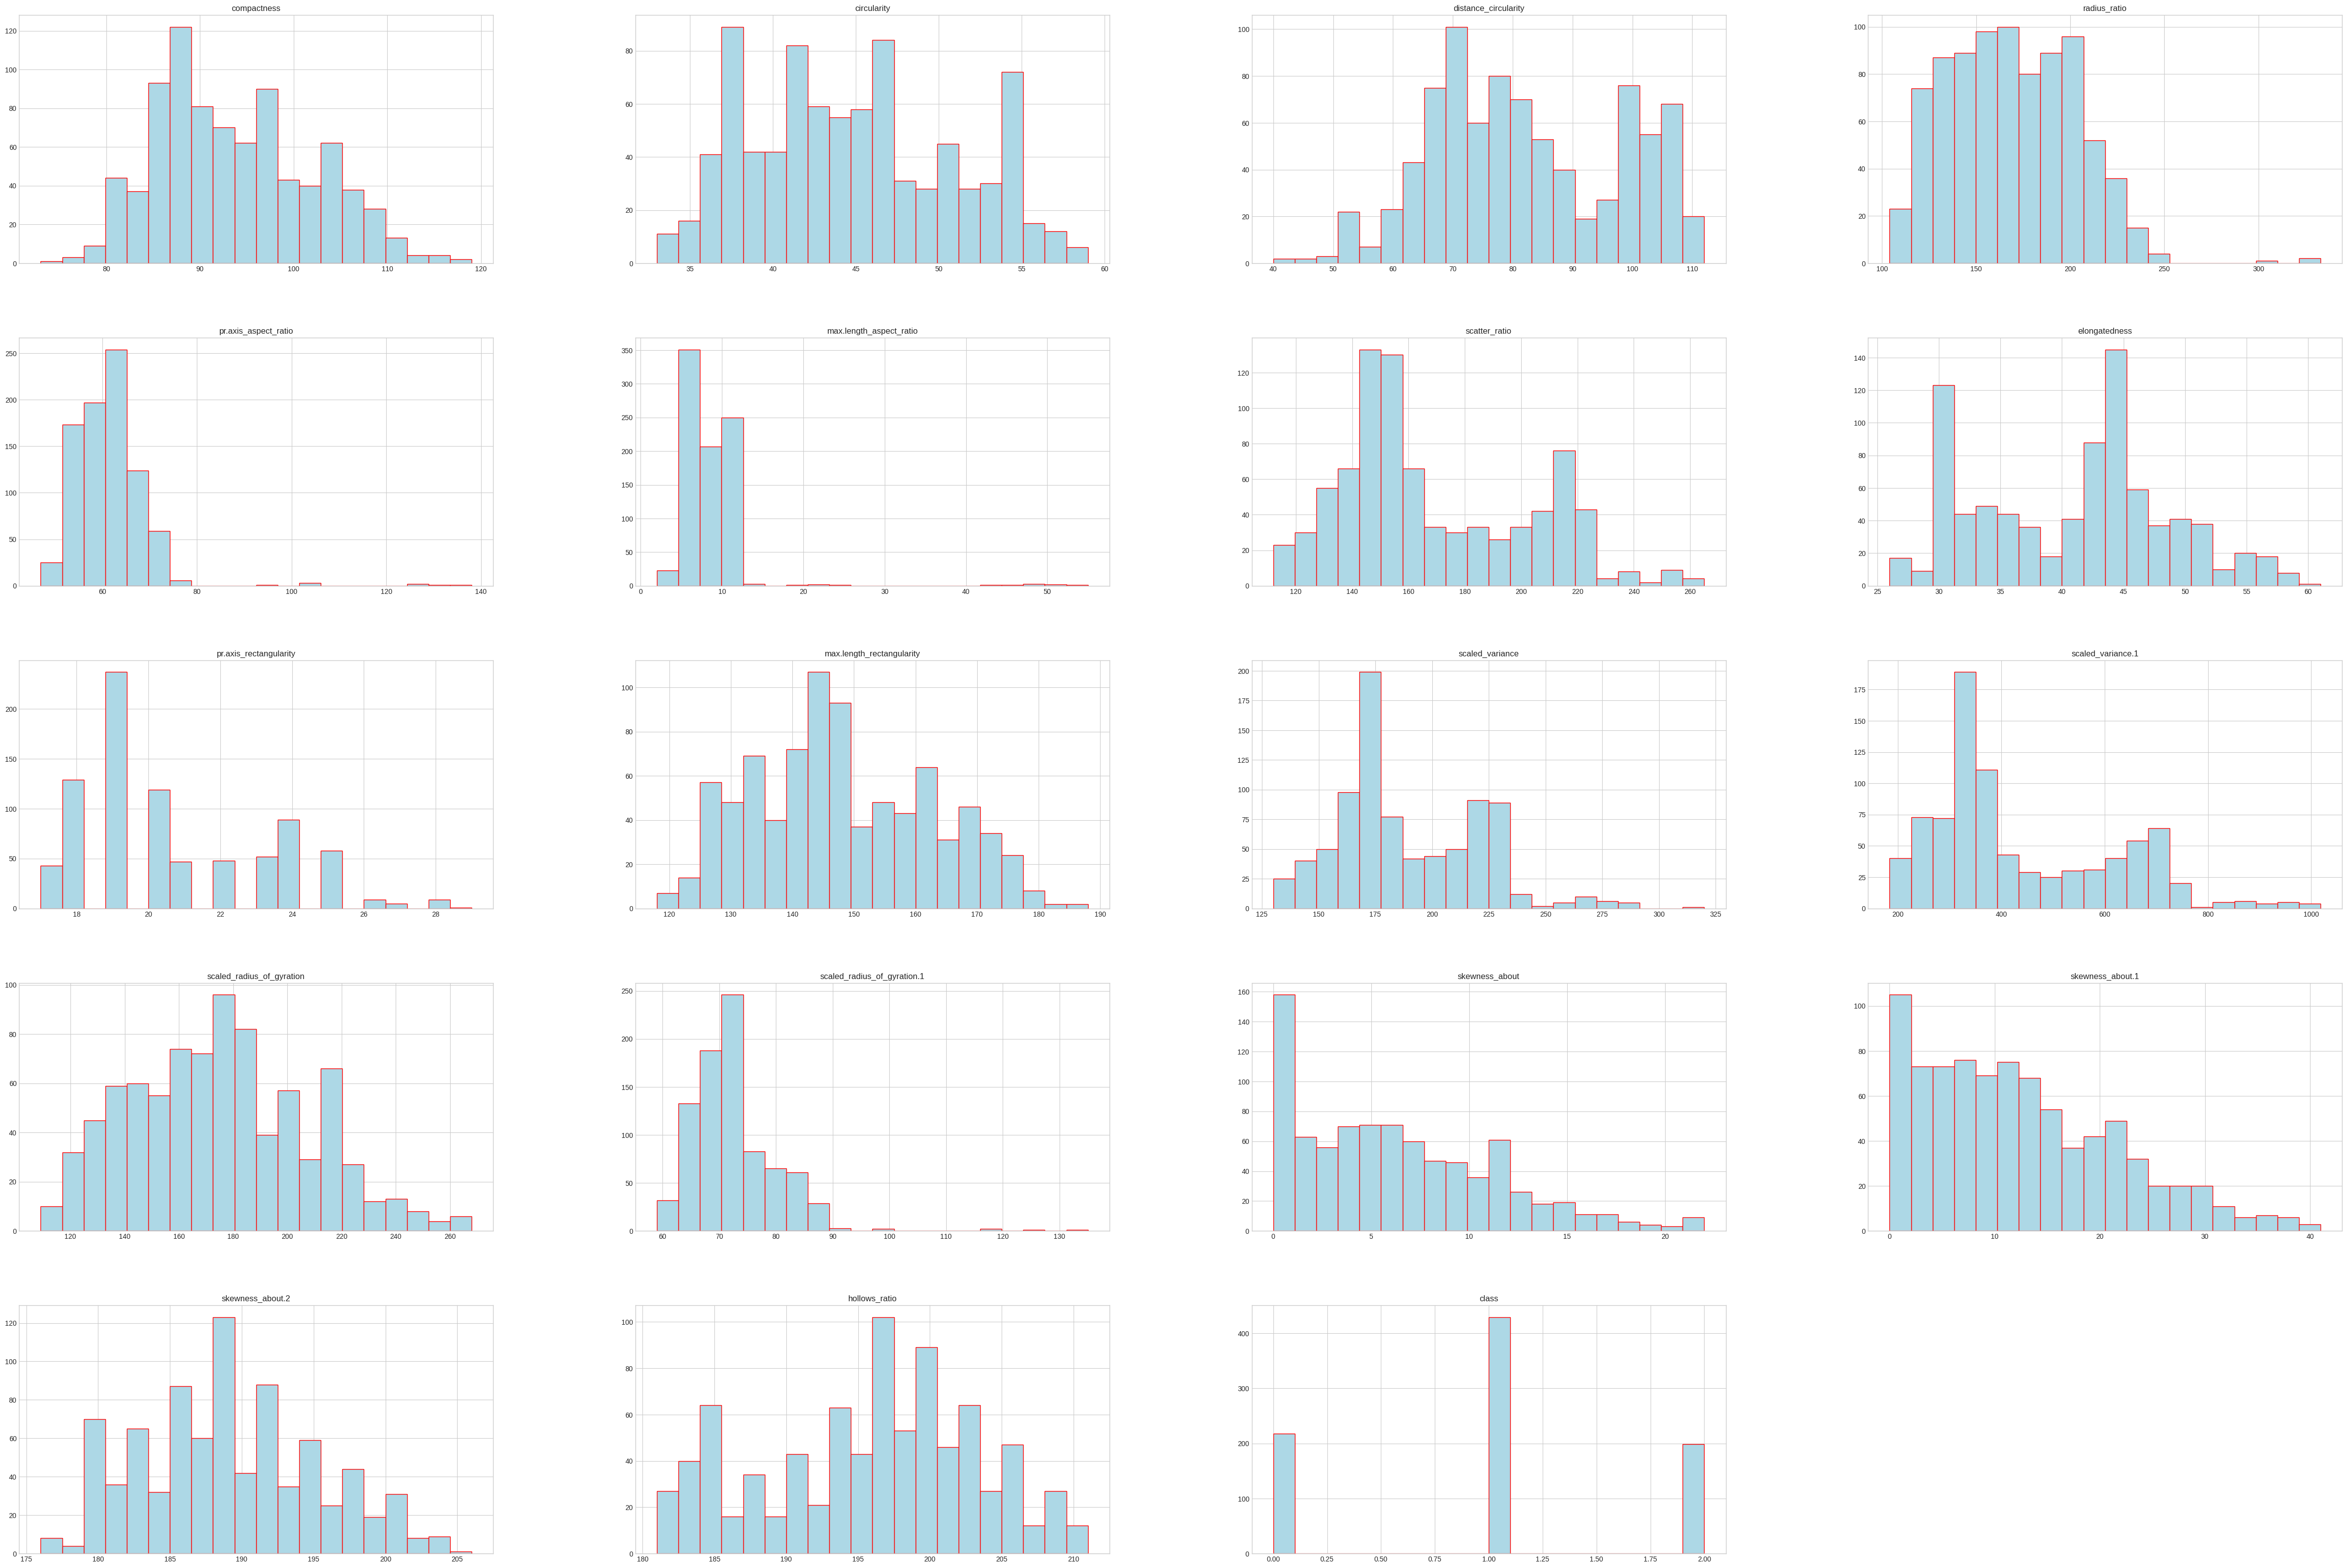

In [ ]:
plt.style.use('seaborn-whitegrid')

newdf.hist(bins=20, figsize=(60,40), color='lightblue', edgecolor = 'red')
plt.show()

Quick Observation :
   - Most of the data attributes seems to be normally distributed
   - scaled valriance 1 and skewness about 1 and 2, scatter_ratio, seems to be right skwed .
   - pr.axis_rectangularity seems to be haing outliers as there are some gaps found in the bar plot.

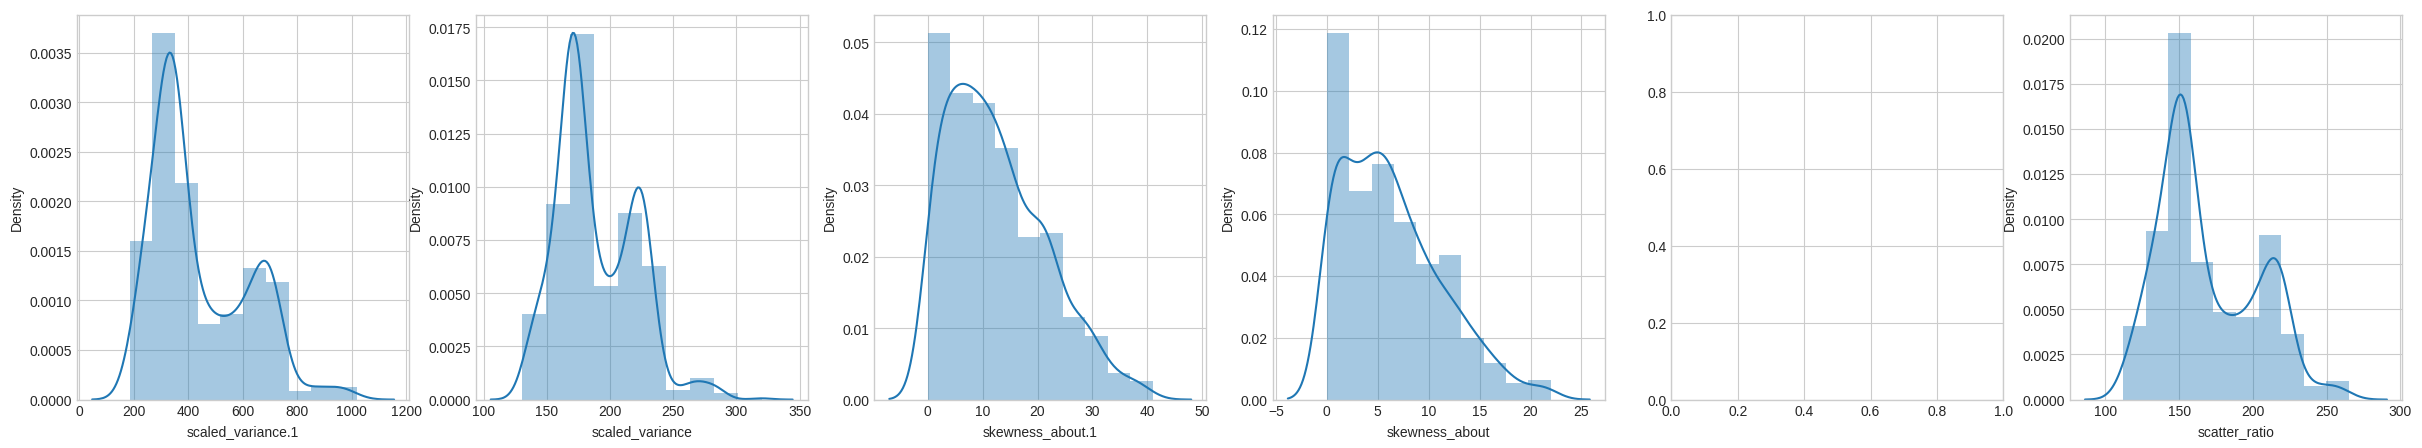

In [ ]:
#Let us use seaborn distplot to analyze the distribution of our columns and see the skewness in attributes
f, ax = plt.subplots(1, 6, figsize=(30,5))
vis1 = sns.distplot(newdf["scaled_variance.1"],bins=10, ax= ax[0])
vis2 = sns.distplot(newdf["scaled_variance"],bins=10, ax=ax[1])
vis3 = sns.distplot(newdf["skewness_about.1"],bins=10, ax= ax[2])
vis4 = sns.distplot(newdf["skewness_about"],bins=10, ax=ax[3])
vis6 = sns.distplot(newdf["scatter_ratio"],bins=10, ax=ax[5])

f.savefig('subplot.png')

In [ ]:
skewValue = newdf.skew()
print("skewValue of dataframe attributes: ", skewValue)

skewValue of dataframe attributes:  compactness                    0.381271
circularity                    0.264928
distance_circularity           0.108718
radius_ratio                   0.397572
pr.axis_aspect_ratio           3.835392
max.length_aspect_ratio        6.778394
scatter_ratio                  0.608710
elongatedness                  0.046951
pr.axis_rectangularity         0.774406
max.length_rectangularity      0.256359
scaled_variance                0.655598
scaled_variance.1              0.845345
scaled_radius_of_gyration      0.279910
scaled_radius_of_gyration.1    2.089979
skewness_about                 0.780813
skewness_about.1               0.689014
skewness_about.2               0.249985
hollows_ratio                 -0.226341
class                          0.031106
dtype: float64


# Univariate Analysis Using Boxplot:

In descriptive statistics, a box plot is a method for graphically depicting groups of numerical data through their quartiles. Box plots may also have lines extending vertically from the boxes (whiskers) indicating variability outside the upper and lower quartiles, hence the terms box-and-whisker plot and box-and-whisker diagram. Outliers may be plotted as individual points.


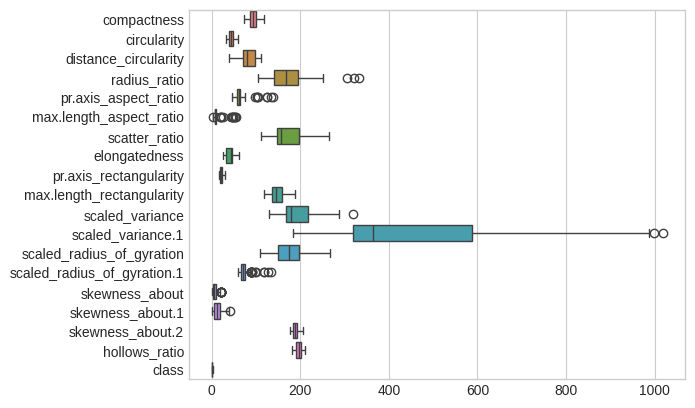

In [ ]:
#Summary View of all attribute , The we will look into all the boxplot individually to trace out outliers

ax = sns.boxplot(data=newdf, orient="h")


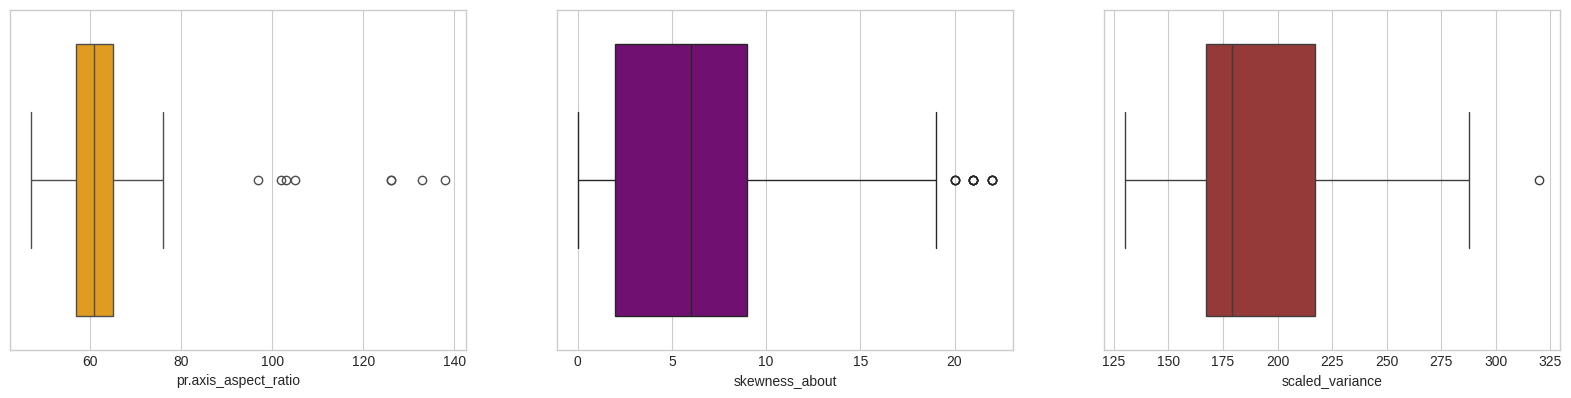

In [ ]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= newdf['pr.axis_aspect_ratio'], color='orange')

plt.subplot(3,3,2)
sns.boxplot(x= newdf.skewness_about, color='purple')

plt.subplot(3,3,3)
sns.boxplot(x= newdf.scaled_variance, color='brown')

plt.show()



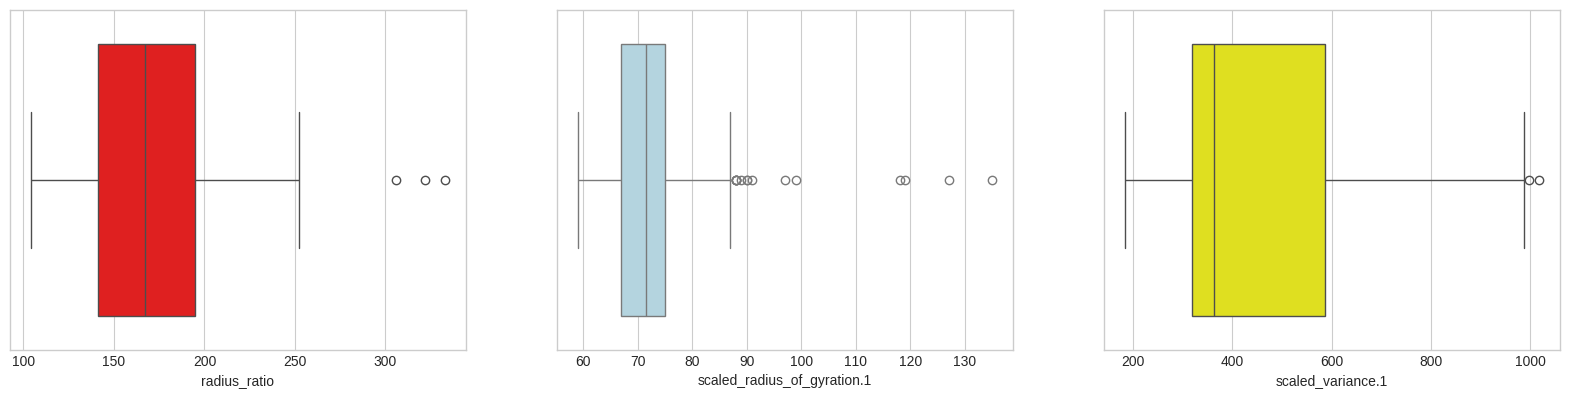

In [ ]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= newdf['radius_ratio'], color='red')

plt.subplot(3,3,2)
sns.boxplot(x= newdf['scaled_radius_of_gyration.1'], color='lightblue')

plt.subplot(3,3,3)
sns.boxplot(x= newdf['scaled_variance.1'], color='yellow')

plt.show()

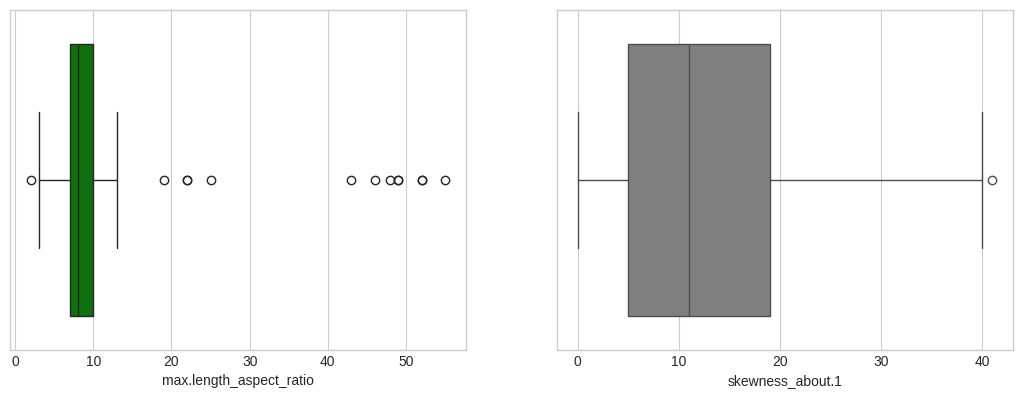

In [ ]:
plt.figure(figsize= (20,15))
plt.subplot(3,3,1)
sns.boxplot(x= newdf['max.length_aspect_ratio'], color='green')

plt.subplot(3,3,2)
sns.boxplot(x= newdf['skewness_about.1'], color='grey')


plt.show()

# Observation on boxplots:
   - pr.axis_aspect_ratio, skewness_about, max_length_aspect_ratio, skewness_about_1,
   - scaled_radius_of_gyration.1, scaled_variance.1, radius_ratio, skewness_about, scaled_variance.1
 are some of the attributes with outliers. which is visible with all dotted points   

## Treating Outliers Using IQR: Upper whisker

The interquartile range (IQR), also called the midspread or middle 50%, or technically H-spread, is a measure of statistical dispersion, being equal to the difference between 75th and 25th percentiles, or between upper and lower quartiles, IQR = Q3 − Q1.
  

In [ ]:
newdf.shape


(846, 19)

### As we now have the IQR scores, it’s time to get hold on outliers. The below code will give an output with some true and false values. The data point where we have False that means these values are valid whereas True indicates presence of an outlier.

In [ ]:
from scipy.stats import iqr

Q1 = newdf.quantile(0.25)
Q3 = newdf.quantile(0.75)
IQR = Q3 - Q1
print(IQR)




compactness                     13.00
circularity                      9.00
distance_circularity            28.00
radius_ratio                    54.00
pr.axis_aspect_ratio             8.00
max.length_aspect_ratio          3.00
scatter_ratio                   51.00
elongatedness                   13.00
pr.axis_rectangularity           4.00
max.length_rectangularity       22.00
scaled_variance                 50.00
scaled_variance.1              268.50
scaled_radius_of_gyration       49.00
scaled_radius_of_gyration.1      8.00
skewness_about                   7.00
skewness_about.1                14.00
skewness_about.2                 9.00
hollows_ratio                   10.75
class                            1.00
dtype: float64


In [ ]:
cleandf = newdf[~((newdf < (Q1 - 1.5 * IQR)) |(newdf > (Q3 + 1.5 * IQR))).any(axis=1)]
cleandf.shape

(813, 19)

## Let's Plot The Box Plot Once Agaian To See if outliers are removed.

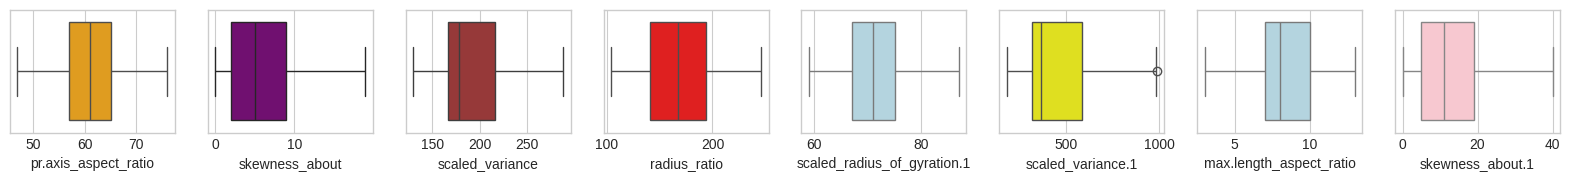

In [ ]:
plt.figure(figsize= (20,15))
plt.subplot(8,8,1)
sns.boxplot(x= cleandf['pr.axis_aspect_ratio'], color='orange')

plt.subplot(8,8,2)
sns.boxplot(x= cleandf.skewness_about, color='purple')

plt.subplot(8,8,3)
sns.boxplot(x= cleandf.scaled_variance, color='brown')
plt.subplot(8,8,4)
sns.boxplot(x= cleandf['radius_ratio'], color='red')

plt.subplot(8,8,5)
sns.boxplot(x= cleandf['scaled_radius_of_gyration.1'], color='lightblue')

plt.subplot(8,8,6)
sns.boxplot(x= cleandf['scaled_variance.1'], color='yellow')

plt.subplot(8,8,7)
sns.boxplot(x= cleandf['max.length_aspect_ratio'], color='lightblue')

plt.subplot(8,8,8)
sns.boxplot(x= cleandf['skewness_about.1'], color='pink')

plt.show()


### Quick Comment:

We can see that all out boxplot for all the attributes which had outlier have been treate and removed. Since no. of outliers were less we opted to remove it. Generally we avoid this as it can lead to info loss in case of large data sets with large no of outliers

# Understanding the relationship between all independent attribute:

We will be using data correlation:

Data Correlation: Is a way to understand the relationship between multiple variables and attributes in your dataset. Using Correlation, you can get some insights such as:

- One or multiple attributes depend on another attribute or a cause for another attribute.
- One or multiple attributes are associated with other attributes.

Spearman and Pearson are two statistical methods to calculate the strength of correlation between two variables or attributes. Pearson Correlation Coefficient can be used with continuous variables that have a linear relationship.

## Pearson Correlation Coefficient:

We will use Pearson Correlation Coefficient to see what all attributes are linearly related and also visualize the same in the seaborns scatter plot.


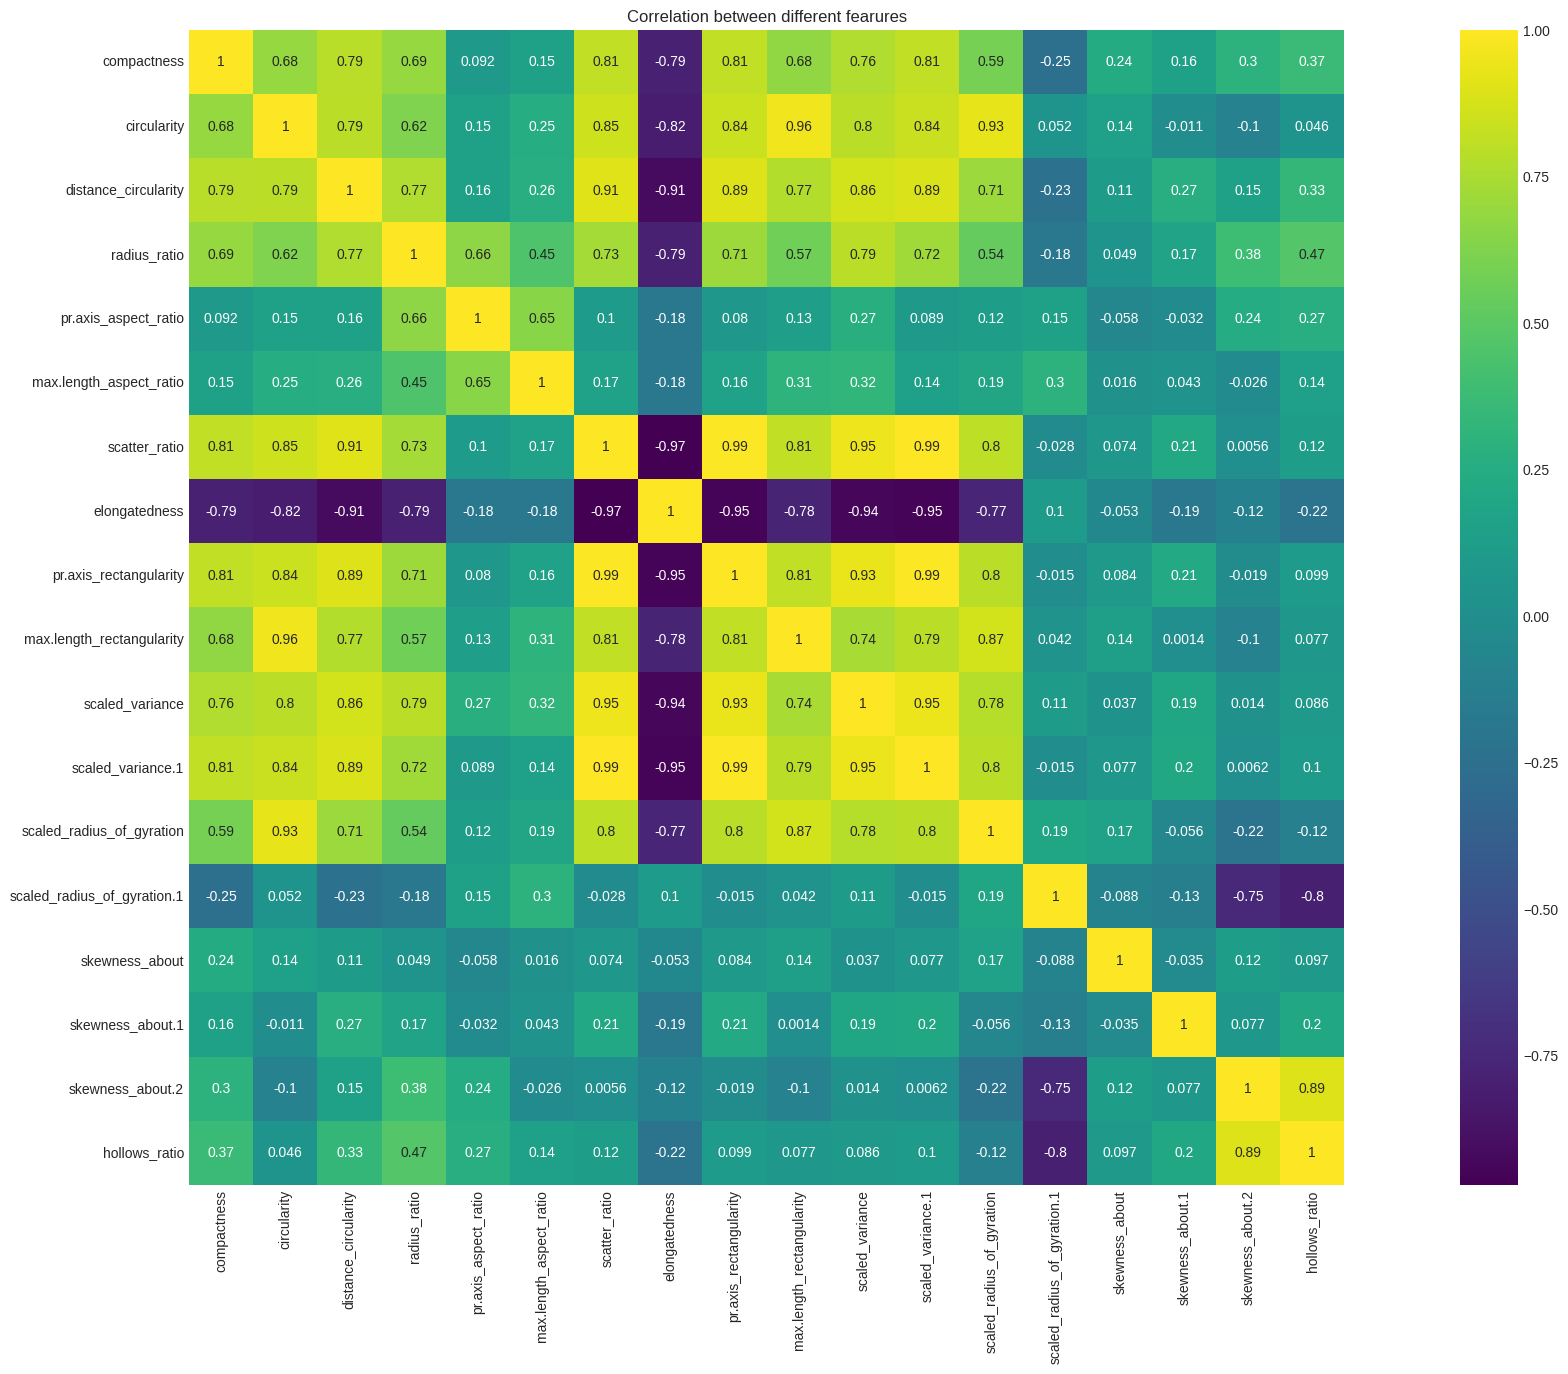

In [ ]:
def correlation_heatmap(dataframe,l,w):
    #correlations = dataframe.corr()
    correlation = dataframe.corr()
    plt.figure(figsize=(l,w))
    sns.heatmap(correlation, vmax=1, square=True,annot=True,cmap='viridis')
    plt.title('Correlation between different fearures')
    plt.show();

# Let's Drop Class column and see the correlation Matrix & Pairplot Before using this dataframe for PCA as PCA should only be perfromed on independent attribute
cleandf= newdf.drop('class', axis=1)
#print("After Dropping: ", cleandf)
correlation_heatmap(cleandf, 30,15)

## Quick Insights : From Correlation Hetamap:

### Strong/fare Correlation:

          - Scaled Variance & Scaled Variance.1 seems to be strongly correlated with value of 0.98
          - skewness_about_2 and hollow_ratio seems to be strongly correlated, corr coeff: 0.89
          - ditance_circularity and radius_ratio seems to have high positive correlation with corr coeff: 0.81
          - compactness & circularity , radius_ratio & pr.axis_aspect_ratio also seems ver averagely correlated with coeff: 0.67.
          - scaled _variance and scaled_radius_of_gyration, circularity & distance_circularity also seems to be highly correlated with corr coeff: 0.79
          - pr.axis_recatngularity and max.length_recatngularity also seems to be strongly correlated with coeff: 0.81
          - scatter_ratio and elongatedness seems to be have strong negative correlation val : 0.97
          - elongatedness and pr.axis_rectangularity seems to have strong negative correlation, val:  0.95
       
          
   
### Little To No Correlation:
          -  
          -max_length_aspect_ratio & radius_ratio have average correlation with coeff: 0.5
          - pr.axis_aspect_ratio & max_length_aspect_ratio seems to have very little correlation
          - scaled_radius_gyration & scaled_radisu_gyration.1 seems to be very little correlated
          - scaled_radius_gyration.1 & skewness_about seems to be very little correlated
          - skewness_about & skewness_about.1 not be correlated
          - skewness_about.1 and skewness_about.2 are not correlated.
        
let's visualize the same with pairplot , to see how it looks visually .

        
## Pairplot Analysis:           

In [ ]:
sns.pairplot(cleandf, diag_kind="kde")

## Quick Insights:
As observed in our correlation heatmap our pairplot seems to validate the same. Scaled Variance & Scaled Variance.1 seems to be have very strong positive correlation with value of 0.98. skewness_about_2 and hollow_ratio also seems to have strong positive correation with coeff: 0.89

scatter_ratio and elongatedness seems to be have very strong negative correlation. elongatedness and pr.axis_rectangularity seems to have strong negative correlation with val of


We found from our pairplot analysis that, Scaled Variance & Scaled Variance.1 and elongatedness and pr.axis_rectangularity to be strongly correlated , so they need to dropped of treated carefully before we go for model building.

## Choosing the right attributes which can be the right choice for model building

since our objective is to reocgnize whether an object is a van or bus or car based on some input features. so our main assumption is there is little or no multicollinearity between the features. if our dataset has perfectly positive or negative attributes as can be obseverd fro our correlation analysis, there is a high chance that the performance of the model will be impacted by a problem called — “Multicollinearity”. Multicollinearity happens when one predictor variable in a multiple regression model can be linearly predicted from the others with a high degree of accuracy. This can lead to skewed or misleading results.

if two features is highly correlated then there is no point using both features.in that case, we can drop one feature. SNS heatmap gives us the correlation matrix where we can see which features are highly correlated.

From above correlation matrix we can see that there are many features which are highly correlated. if we carefully analyse, we will find that many  features are there which having more than 0.9 correlation. so we can decide to get rid of those columns whose correlation is +-0.9 or above.There are 8 such columns:

- max.length_rectangularity
- scaled_radius_of_gyration
- skewness_about.2
- scatter_ratio
- elongatedness
- pr.axis_rectangularity
- scaled_variance
- scaled_variance.1

### Outcome:
Also we observed that more than 50 % of our attributes ar highly correlated , so  what we can we do best to deal with this kind problem of Multicollinearity

### Well, There are multiple ways to deal with this problem. The easiest way is to delete or eliminate one of the perfectly correlated features.  We can pick one of the tiwo highly correalated variables and drop another one. like in our case Scaled Variance & Scaled Variance.1 are having strong positive correlation , so we can pick one and drop one as they will only make our dimension redundant.

### Similarly between elongatedness and pr.axis_rectangularity we can pick one as they have very strong negative correlation. This approach can be used to select the feature we want to carry forward for model analysis. But there is another better approach called PCA

### Another method, is to use a dimension reduction algorithm such as Principle Component Analysis (PCA). We will go for PCA and analyse the same going forward:


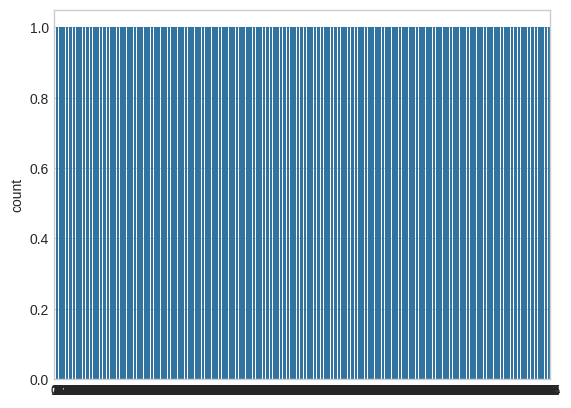

In [ ]:
#display how many are car,bus,van.
newdf['class'].value_counts()

splitscaledf = newdf.copy()
sns.countplot(newdf['class'])
plt.show()


# Principal Component Analysis(PCA):

     - Basically PCA is a dimension redcuction methodology which aims to reduce a large set of (often correlated) variables into a smaller set of (uncorrelated) variables, called principal components, which holds sufficient information without loosing the the relevant info much.
     
     - Principal components are new variables that are constructed as linear combinations or mixtures of the initial variables. These combinations are done in such a way that the new variables (i.e., principal components) are uncorrelated and most of the information within the initial variables is squeezed or compressed into the first components.
     
## We will perform PCA in following steps:
   - Split our data into train and test data set
   - normalize the tarining set using standard scalar
   - Calculate the covariance matrix.
   - Calculate the eigenvectors and their eigenvalues.
   - Sort the eigenvectors according to their eigenvalues in descending order.
   - Choose the first K eigenvectors (where k is the dimension we'd like to end up with).
   - Build new dataset with reduced dimensionality.
   

# Approach 1:

### Separate The Data Into Independent & Dependent attribute


In [ ]:
#now separate the dataframe into dependent and independent variables
#X1= newdf.drop('class',axis=1)
#y1 = newdf['class']
#print("shape of new_vehicle_df_independent_attr::",X.shape)
#print("shape of new_vehicle_df_dependent_attr::",y.shape)

X = newdf.iloc[:,0:18].values
y = newdf.iloc[:,18].values

X

array([[ 95.,  48.,  83., ...,  16., 187., 197.],
       [ 91.,  41.,  84., ...,  14., 189., 199.],
       [104.,  50., 106., ...,   9., 188., 196.],
       ...,
       [106.,  54., 101., ...,   4., 187., 201.],
       [ 86.,  36.,  78., ...,  25., 190., 195.],
       [ 85.,  36.,  66., ...,  18., 186., 190.]])

### Scaling The Independent Data Set:

In [ ]:
from sklearn.preprocessing import StandardScaler
#We transform (centralize) the entire X (independent variable data) to normalize it using standardscalar through transformation. We will create the PCA dimensions
# on this distribution.
sc = StandardScaler()
X_std =  sc.fit_transform(X)


## Calculating covariance matrix:

Covariance matrix should be 18*18 matrix


In [ ]:

cov_matrix = np.cov(X_std.T)
print("cov_matrix shape:",cov_matrix.shape)
print("Covariance_matrix",cov_matrix)

cov_matrix shape: (18, 18)
Covariance_matrix [[ 1.00118343  0.68569786  0.79086299  0.69055952  0.09164265  0.14842463
   0.81358214 -0.78968322  0.81465658  0.67694334  0.76297234  0.81497566
   0.58593517 -0.24988794  0.23635777  0.15720044  0.29889034  0.36598446]
 [ 0.68569786  1.00118343  0.79325751  0.6216467   0.15396023  0.25176438
   0.8489411  -0.82244387  0.84439802  0.96245572  0.79724837  0.83693508
   0.92691166  0.05200785  0.14436828 -0.01145212 -0.10455005  0.04640562]
 [ 0.79086299  0.79325751  1.00118343  0.76794246  0.15864319  0.26499957
   0.90614687 -0.9123854   0.89408198  0.77544391  0.86253904  0.88706577
   0.70660663 -0.22621115  0.1140589   0.26586088  0.14627113  0.33312625]
 [ 0.69055952  0.6216467   0.76794246  1.00118343  0.66423242  0.45058426
   0.73529816 -0.79041561  0.70922371  0.56962256  0.79435372  0.71928618
   0.53700678 -0.18061084  0.04877032  0.17394649  0.38266622  0.47186659]
 [ 0.09164265  0.15396023  0.15864319  0.66423242  1.00118343  

## Calculating Eigen Vectors & Eigen Values: Using numpy linear algebra function


In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[ 2.75283688e-01  1.26953763e-01 -1.19922479e-01  7.83843562e-02
   6.95178336e-02 -1.44875476e-01 -4.51862331e-01 -5.66136785e-01
  -4.84418105e-01 -2.60076393e-01  4.65342885e-02 -1.20344026e-02
  -1.56136836e-01 -1.00728764e-02 -6.00532537e-03  6.00485194e-02
  -6.50956666e-02 -9.67780251e-03]
 [ 2.93258469e-01 -1.25576727e-01 -2.48205467e-02  1.87337408e-01
  -8.50649539e-02  3.02731148e-01  2.49103387e-01 -1.79851809e-01
  -1.41569001e-02  9.80779086e-02  3.01323693e-03  2.13635088e-01
  -1.50116709e-02 -9.15939674e-03  7.38059396e-02 -4.26993118e-01
  -2.61244802e-01 -5.97862837e-01]
 [ 3.04609128e-01  7.29516436e-02 -5.60143254e-02 -7.12008427e-02
   4.06645651e-02  1.38405773e-01 -7.40350569e-02  4.34748988e-01
  -1.67572478e-01 -2.05031597e-01  7.06489498e-01 -3.46330345e-04
   2.37111452e-01  6.94599696e-03 -2.50791236e-02  1.46240270e-01
   7.82651714e-02 -1.57257142e-01]
 [ 2.67606877e-01  1.89634378e-01  2.75074211e-01 -4.26053415e-02
  -4.61473714e-02 -

## Sort eigenvalues in descending order

In [ ]:

# Make a set of (eigenvalue, eigenvector) pairs:

eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(9.404602609088712, array([ 0.27528369,  0.29325847,  0.30460913,  0.26760688,  0.08050399,
        0.09727569,  0.31709275, -0.31413315,  0.31395906,  0.2828309 ,
        0.30928036,  0.31378846,  0.27204749, -0.02081377,  0.04145551,
        0.05822502,  0.03027951,  0.07414539])), (3.014922058524634, array([ 0.12695376, -0.12557673,  0.07295164,  0.18963438,  0.12217486,
       -0.01074829, -0.04811814, -0.01274985, -0.05993525, -0.11622053,
       -0.06228062, -0.05378436, -0.20923317, -0.48852515,  0.05508997,
        0.12408509,  0.54091477,  0.54035426])), (1.9035250218389683, array([-0.11992248, -0.02482055, -0.05601433,  0.27507421,  0.64201297,
        0.5918013 , -0.09762831,  0.05764844, -0.10951242, -0.0170642 ,
        0.05632398, -0.10884073, -0.03146365,  0.28627701, -0.11567935,
       -0.07528289,  0.00873592,  0.03952427])), (1.1799374684450206, array([ 0.07838436,  0.18733741, -0.07120084, -0.04260534,  0.03272571,
        0.03141473, -0.09574857,  0.0822902 , -0.0

In [ ]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each
# eigen vector... there will be 18 entries as there are 18 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 18 entries with 18 th entry
# cumulative reaching almost 100%

## Plotting The Explained Variance and Princiapl Components:  

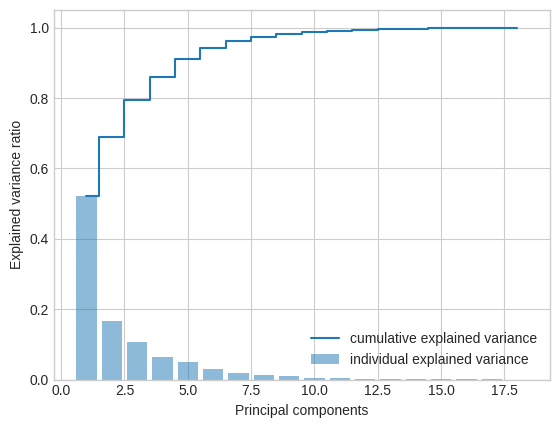

In [ ]:

plt.bar(range(1,19), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,19),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

### Quick Observation:
    - From above we plot we can clealry observer that 8 dimension() are able to explain 95 %variance of data.
    - so we will use first 8 principal components going forward and calulate the reduced dimensions.

## Dimensionality Reduction

Now 8 dimensions seems very reasonable. With 8 variables we can explain over 95% of the variation in the original data!

In [ ]:
# P_reduce represents reduced mathematical space....

P_reduce = np.array(eigvectors_sorted[0:8])   # Reducing from 8 to 4 dimension space

X_std_8D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions

reduced_pca = pd.DataFrame(X_std_8D)  # converting array to dataframe for pairplot

reduced_pca

,0,1,2,3,4,5,6,7
0,0.334162,0.219026,1.001584,0.176612,0.079301,0.757447,0.901124,-0.381106
1,-1.591711,0.420603,-0.369034,0.233234,0.693949,0.517162,-0.378637,0.247059
2,3.769324,-0.195283,0.087859,1.202212,0.731732,-0.705041,0.034584,0.482772
3,-1.738598,2.829692,0.109456,0.376685,-0.362897,0.484431,-0.470753,-0.023086
4,0.558103,-4.758422,11.703647,0.147464,3.256953,0.203446,-2.671578,-0.448854
...,...,...,...,...,...,...,...,...
841,-0.442648,0.605884,0.197213,-1.444958,1.065425,-0.820179,0.041563,0.506991
842,-0.314956,-0.164511,0.794573,-0.908272,-0.235492,1.438257,0.599113,-0.153086
843,4.809174,0.001249,0.532333,0.295652,-1.344236,0.217070,-0.573249,0.110478
844,-3.294092,1.008276,-0.357003,-1.933675,0.042768,0.402491,0.202406,0.320622


### Let us check The Pairplot Of Reduced Dimension After PCA:

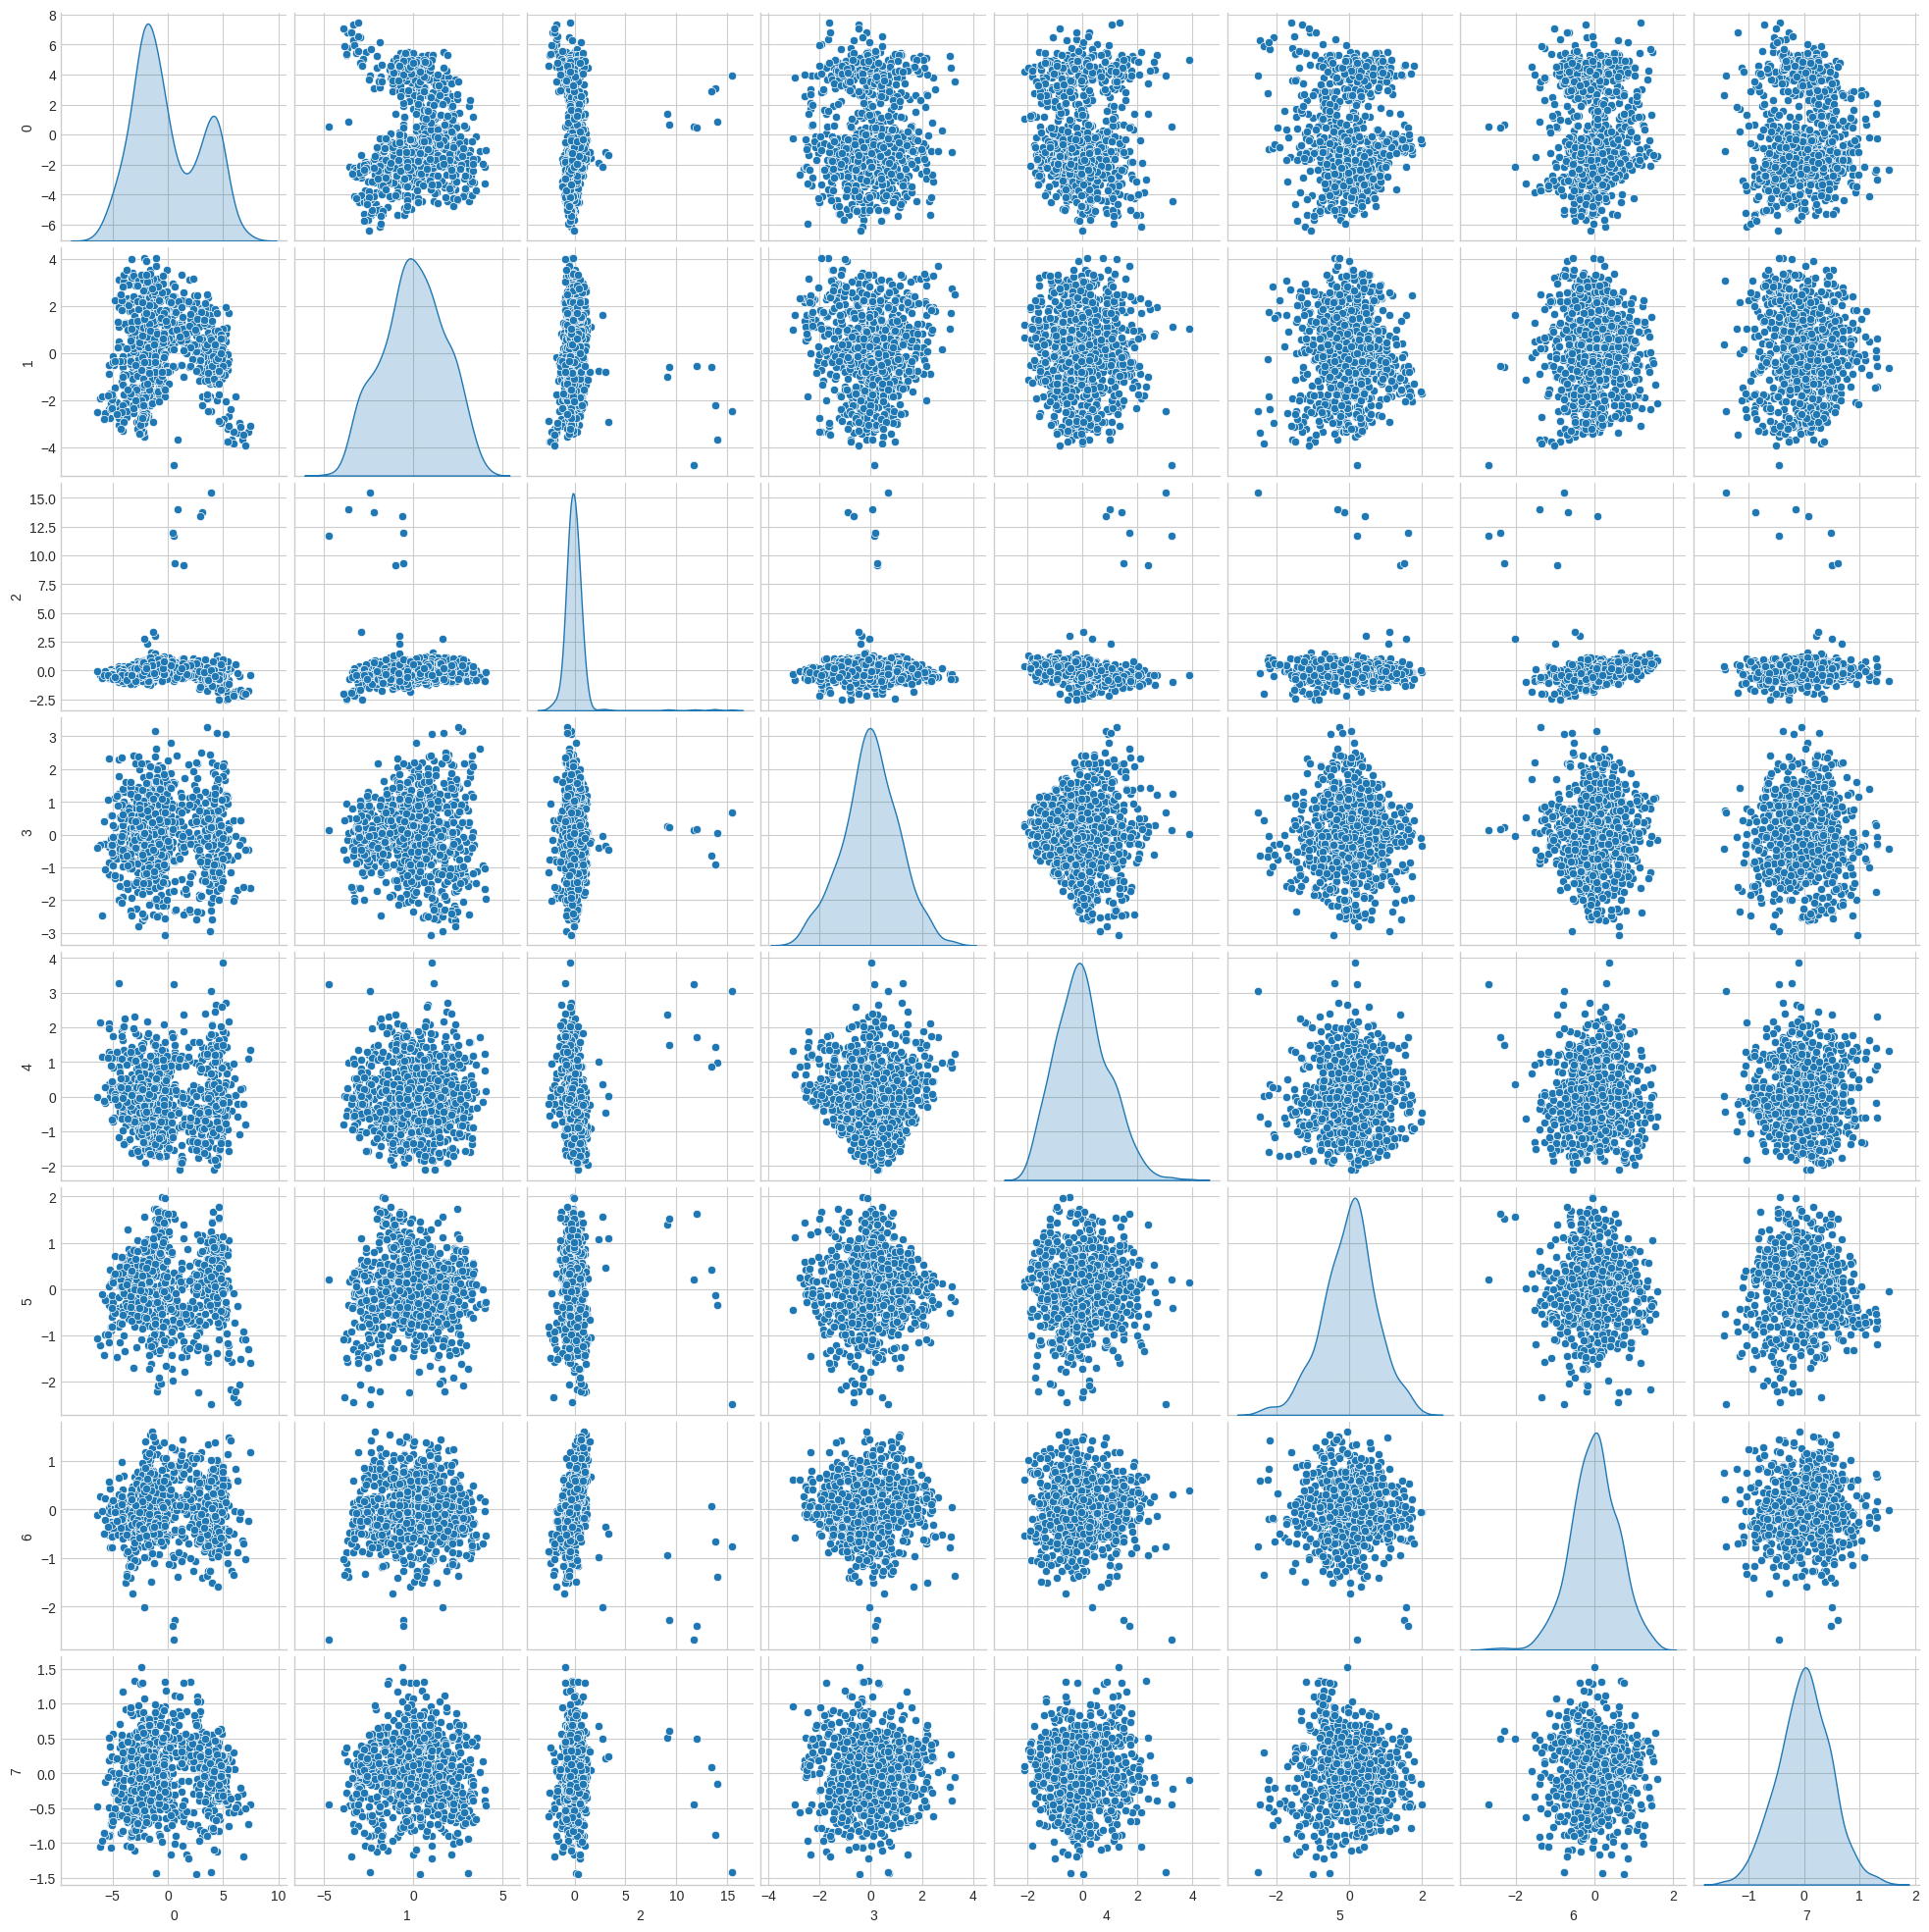

In [ ]:

sns.pairplot(reduced_pca, diag_kind='kde')
#sns.pairplot(reduced_pca1, diag_kind='kde')

### It is clealry visible from the pairplot above that:
After dimensionality reduction using PCA our attributes have become independent with no correlation among themselves. As most of them have cloud of data points with no lienaer kind of relationship.

## Fitting Model and measuring score simply on Original Data :

### Fit SVC Model ON Train-test Data:

Let's build two Support Vector Classifier Model one with 18 original independent variables and the second one with only the 8 new reduced variables constructed using PCA.

In [ ]:
#now split the data into 70:30 ratio

#orginal Data
Orig_X_train,Orig_X_test,Orig_y_train,Orig_y_test = train_test_split(X_std,y,test_size=0.30,random_state=1)

#PCA Data
pca_X_train,pca_X_test,pca_y_train,pca_y_test = train_test_split(reduced_pca,y,test_size=0.30,random_state=1)
#pca_X_train,pca_X_test,pca_y_train,pca_y_test = train_test_split(reduced_pca1,y,test_size=0.30,random_state=1)

# Let's train the model with both original data and pca data with new dimension

### Fitting SVC model On Original Data

In [ ]:

svc = SVC() #instantiate the object


In [ ]:
#fit the model on orighinal raw data
svc.fit(Orig_X_train,Orig_y_train)

SVC()

In [ ]:
#predict the y value
Orig_y_predict = svc.predict(Orig_X_test)



### Fitting SVC ON PCA Data:

In [ ]:
#now fit the model on pca data with new dimension
svc1 = SVC() #instantiate the object
svc1.fit(pca_X_train,pca_y_train)

#predict the y value
pca_y_predict = svc1.predict(pca_X_test)

In [ ]:
#display accuracy score of both models

print("Model Score On Original Data ",svc.score(Orig_X_test, Orig_y_test))
print("Model Score On Reduced PCA Dimension ",svc1.score(pca_X_test, pca_y_test))

print("Before PCA On Original 18 Dimension",accuracy_score(Orig_y_test,Orig_y_predict))
print("After PCA(On 8 dimension)",accuracy_score(pca_y_test,pca_y_predict))

Model Score On Original Data  0.952755905511811
Model Score On Reduced PCA Dimension  0.937007874015748
Before PCA On Original 18 Dimension 0.952755905511811
After PCA(On 8 dimension) 0.937007874015748


### Quick Observation:
   - On training data set we saw that our support vector classifier without performing PCA has an accuracy score of 95 %
   - But when we applied the SVC model on PCA componenets(reduced dimensions) our model scored 93 %.
   - Considering that original dataframe had 18 dimensions and After PCA dimension reduced to 8, our model has fared well in terms of accuracy score.

### Confusion Matrix:


Confusion Matrix For: 
 Original Data Set 
 [[ 58   0   1]
 [  1 129   3]
 [  6   1  55]]


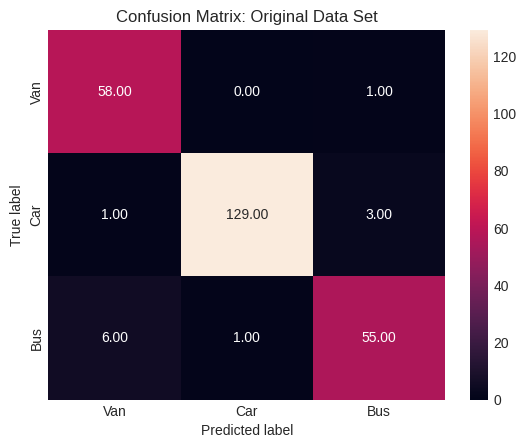

Confusion Matrix For: 
 For Reduced Dimensions Using PCA 
 [[ 57   1   1]
 [  2 126   5]
 [  5   2  55]]


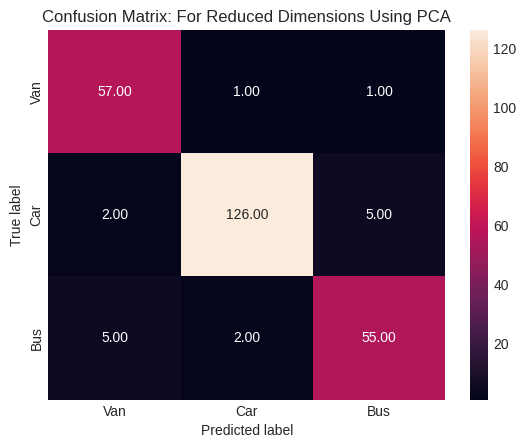

Classification Report For Raw Data: 
               precision    recall  f1-score   support

         0.0       0.89      0.98      0.94        59
         1.0       0.99      0.97      0.98       133
         2.0       0.93      0.89      0.91        62

    accuracy                           0.95       254
   macro avg       0.94      0.95      0.94       254
weighted avg       0.95      0.95      0.95       254

Classification Report For PCA: 
               precision    recall  f1-score   support

         0.0       0.89      0.97      0.93        59
         1.0       0.98      0.95      0.96       133
         2.0       0.90      0.89      0.89        62

    accuracy                           0.94       254
   macro avg       0.92      0.93      0.93       254
weighted avg       0.94      0.94      0.94       254



In [ ]:
def draw_confmatrix(y_test, yhat, str1, str2, str3, datatype):
    # Make predictions and evaluate
    cm = confusion_matrix(y_test, yhat, labels=[0, 1, 2])
    print("Confusion Matrix For:", "\n", datatype, "\n", cm)
    sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=[str1, str2, str3], yticklabels=[str1, str2, str3])
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Confusion Matrix: {datatype}')
    plt.show()

# Assuming Orig_y_test, Orig_y_predict, pca_y_test, and pca_y_predict are defined

draw_confmatrix(Orig_y_test, Orig_y_predict, "Van", "Car", "Bus", "Original Data Set")
draw_confmatrix(pca_y_test, pca_y_predict, "Van", "Car", "Bus", "For Reduced Dimensions Using PCA")

# Classification Report Of Model built on Raw Data
print("Classification Report For Raw Data:", "\n", classification_report(Orig_y_test, Orig_y_predict))

# Classification Report Of Model built on Principal Components
print("Classification Report For PCA:", "\n", classification_report(pca_y_test, pca_y_predict))

### Quick Comments:

### Confusion Metric Analysis ON Original  Data:

Confusion Matrix For :
 Original Data Set
 [[ 58   0   1]
 [  1 129   3]
 [  6   1  55]]
     
       - Our model on original data set has correctly classified 58 van out of 59 actuals vans and has errored only in one case where it has wrongly predicted van to be a bus.  
       - IN case of 133 actual cars our svm model has correcly classified 129 cars. it has wrongly classified 3 cars to be a bus and also 1 car to be a van
       - In case of 62 instances of actual bus , our model has correctly classified 55 buses , It has faltered in classifying wrongly 6 buses to be a van and one bus to be a car.
       
       
### Confusion Metric Analysis ON Reduced Dimesnion After PCA :

For Reduced Dimensions Using PCA:
 [[ 57   2   0]
 [  2 126   5]
 [  1   7  54]]
    
    - Out of 59 actual instances of vans our model has correctly predicted 57 vans and errored in 2 instances where it wrongly classified vans to be a car.
    - Out of 133 actuals cars , our mdoel has correclty classified 126 of them to be a  car and faltered in 7 cases where it wrongly classified 5 cars to a bus and 2 cars to be a van.
    
    - Out of 62 actual bus , our model has correclty classified 54 of them to be a bus. It has faltered in 8 cases where it wrongly classified 7 bus to be a car and 1 bus to be a van.
    
# Let's See The Classification Report Metrics:

Classification Report For Raw Data:
               precision    recall  f1-score   support

         0.0       0.89      0.98      0.94        59
         1.0       0.99      0.97      0.98       133
         2.0       0.93      0.89      0.91        62

   micro avg       0.95      0.95      0.95       254
   macro avg       0.94      0.95      0.94       254
weighted avg       0.95      0.95      0.95       254

Classification Report For PCA:
               precision    recall  f1-score   support

         0.0       0.95      0.97      0.96        59
         1.0       0.93      0.95      0.94       133
         2.0       0.92      0.87      0.89        62

   micro avg       0.93      0.93      0.93       254
   macro avg       0.93      0.93      0.93       254
weighted avg       0.93      0.93      0.93       254


### Insights On Classification Reports:

### On original data:
   
     - our model has 99 % precison  score when it comes to classify car from the given set of silhoutte parameters. It has 89 % precision when it comes to classifying the input as van, while it has 93 % precison when it come to predict data as bus.
     
     - In term of recall score our model has recal score of 98 % for van classification, 97 % for car and 89 % for bus.
     - OUr model has an weighted average of 95 % for all classification metrics.
   
### On Reduced Dimensions After PCA:

     - Our model has highest precision score of 95 % when it comes to predict van type, which is better as compared to predcition done on original data set, which came out with the precision score of 89 % for van.
     - Recall score is almost neck to neck with what our model scored on original data set. It showed highest recall score of 97 % in classifying data as car.

# Approach 2:

# Let's Perfrom The PCA and See How Our Model Perform:

### When we split our data set into test train and then apply scaling.
   
In previous  process of PCA and model performance comparison, we scaled our data before splitting them into train and test, which may have lead to some kind of data leakages. Let's see how our PCA process and model accuracy behaves when we scale our data after splitting the into train-test set
   

In [ ]:
splitscaledf.head(850)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95.0,48.0,83.0,178.0,72.0,10.0,162.0,42.0,20.0,159.0,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197.0,2.0
1,91.0,41.0,84.0,141.0,57.0,9.0,149.0,45.0,19.0,143.0,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199.0,2.0
2,104.0,50.0,106.0,209.0,66.0,10.0,207.0,32.0,23.0,158.0,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196.0,1.0
3,93.0,41.0,82.0,159.0,63.0,9.0,144.0,46.0,19.0,143.0,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207.0,2.0
4,85.0,44.0,70.0,205.0,103.0,52.0,149.0,45.0,19.0,144.0,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,93.0,39.0,87.0,183.0,64.0,8.0,169.0,40.0,20.0,134.0,200.0,422.0,149.0,72.0,7.0,25.0,188.0,195.0,1.0
842,89.0,46.0,84.0,163.0,66.0,11.0,159.0,43.0,20.0,159.0,173.0,368.0,176.0,72.0,1.0,20.0,186.0,197.0,2.0
843,106.0,54.0,101.0,222.0,67.0,12.0,222.0,30.0,25.0,173.0,228.0,721.0,200.0,70.0,3.0,4.0,187.0,201.0,1.0
844,86.0,36.0,78.0,146.0,58.0,7.0,135.0,50.0,18.0,124.0,155.0,270.0,148.0,66.0,0.0,25.0,190.0,195.0,1.0


In [ ]:
splitscale_X = splitscaledf.iloc[:,0:18].values
splitscale_y = splitscaledf.iloc[:,18].values

print("Indpendent Variable X",splitscale_X )
print("Class Variable y",splitscale_y )

Indpendent Variable X [[ 95.  48.  83. ...  16. 187. 197.]
 [ 91.  41.  84. ...  14. 189. 199.]
 [104.  50. 106. ...   9. 188. 196.]
 ...
 [106.  54. 101. ...   4. 187. 201.]
 [ 86.  36.  78. ...  25. 190. 195.]
 [ 85.  36.  66. ...  18. 186. 190.]]
Class Variable y [2. 2. 1. 2. 0. 0. 0. 2. 2. 1. 2. 1. 0. 2. 0. 1. 2. 0. 1. 1. 0. 2. 0. 0.
 1. 2. 1. 1. 0. 1. 2. 1. 1. 1. 1. 2. 0. 2. 1. 0. 1. 2. 2. 1. 1. 2. 2. 0.
 2. 1. 1. 1. 1. 0. 0. 2. 1. 2. 1. 2. 1. 1. 2. 0. 0. 1. 0. 1. 2. 0. 1. 1.
 1. 1. 2. 1. 1. 1. 0. 0. 0. 0. 2. 1. 0. 0. 2. 2. 0. 1. 1. 1. 1. 2. 0. 1.
 1. 0. 1. 0. 0. 2. 2. 2. 0. 1. 1. 1. 0. 0. 2. 2. 1. 1. 2. 2. 1. 1. 0. 0.
 1. 2. 2. 1. 2. 2. 0. 0. 2. 0. 1. 1. 1. 2. 1. 2. 2. 2. 1. 2. 1. 0. 1. 0.
 1. 1. 2. 0. 1. 2. 1. 0. 1. 1. 2. 0. 1. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 2. 1. 0. 2. 0. 2. 0. 1. 0. 0. 2. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 2.
 1. 0. 1. 0. 1. 0. 0. 0. 2. 1. 1. 1. 2. 2. 1. 0. 0. 1. 1. 2. 0. 0. 1. 1.
 1. 1. 0. 2. 1. 2. 0. 0. 1. 2. 1. 2. 1. 1. 2. 1. 0. 1. 2. 2. 0. 0. 1. 0.
 1.

## Let's Split Our Data Into Test & Train Data Set

In [ ]:
#splitting the data in train and test sets into 70:30 Ratio

SplitScale_X_train, SplitScale_X_test, SplitScale_y_train, SplitScale_y_test = train_test_split(splitscale_X,splitscale_y, test_size = 0.3, random_state = 10)

## Let's Apply StandardScaler to normalize our data set

In [ ]:
ssx_train_sd = StandardScaler().fit_transform(SplitScale_X_train)
ssx_test_sd = StandardScaler().fit_transform(SplitScale_X_test)

print(len(ssx_train_sd))
print(len(ssx_test_sd))


592
254


## Calculating covariance matrix:

Covariance matrix should be 18*18 matrix

In [ ]:
# generating the covariance matrix and the eigen values for the PCA analysis
cov_matrix_1 = np.cov(ssx_train_sd.T) # the relevanat covariance matrix
print('Covariance Matrix \n%s', (cov_matrix_1))

#generating the eigen values and the eigen vectors
e_vals, e_vecs = np.linalg.eig(cov_matrix_1)
print('Eigenvectors \n%s' %(e_vecs))
print('\nEigenvalues \n%s' %e_vals)

Covariance Matrix 
%s [[ 1.00169205  0.69510999  0.79093174  0.68430087  0.10533174  0.13879193
   0.81466568 -0.79249053  0.81562662  0.69493762  0.75883574  0.81360243
   0.6018784  -0.23802643  0.21659465  0.16129088  0.29107259  0.36229106]
 [ 0.69510999  1.00169205  0.80101871  0.63753441  0.17332159  0.23038915
   0.85124238 -0.82911962  0.84353731  0.96223666  0.79821698  0.8377724
   0.92490531  0.04164937  0.12317003  0.0144264  -0.08843129  0.06521593]
 [ 0.79093174  0.80101871  1.00169205  0.76084958  0.1703543   0.25346094
   0.90364003 -0.91115044  0.89344273  0.79364077  0.85618354  0.88392536
   0.72188889 -0.20587281  0.09535999  0.26881961  0.13214005  0.3236881 ]
 [ 0.68430087  0.63753441  0.76084958  1.00169205  0.68494799  0.47133546
   0.72992301 -0.78442329  0.7057782   0.60117669  0.79595443  0.7127739
   0.55325762 -0.13680084  0.02938361  0.17620666  0.36656842  0.46385678]
 [ 0.10533174  0.17332159  0.1703543   0.68494799  1.00169205  0.6847859
   0.10994971 -

### Sort eigenvalues in descending order

In [ ]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(9.404602609088712, array([ 0.27528369,  0.29325847,  0.30460913,  0.26760688,  0.08050399,
        0.09727569,  0.31709275, -0.31413315,  0.31395906,  0.2828309 ,
        0.30928036,  0.31378846,  0.27204749, -0.02081377,  0.04145551,
        0.05822502,  0.03027951,  0.07414539])), (3.014922058524634, array([ 0.12695376, -0.12557673,  0.07295164,  0.18963438,  0.12217486,
       -0.01074829, -0.04811814, -0.01274985, -0.05993525, -0.11622053,
       -0.06228062, -0.05378436, -0.20923317, -0.48852515,  0.05508997,
        0.12408509,  0.54091477,  0.54035426])), (1.9035250218389683, array([-0.11992248, -0.02482055, -0.05601433,  0.27507421,  0.64201297,
        0.5918013 , -0.09762831,  0.05764844, -0.10951242, -0.0170642 ,
        0.05632398, -0.10884073, -0.03146365,  0.28627701, -0.11567935,
       -0.07528289,  0.00873592,  0.03952427])), (1.1799374684450206, array([ 0.07838436,  0.18733741, -0.07120084, -0.04260534,  0.03272571,
        0.03141473, -0.09574857,  0.0822902 , -0.0

In [ ]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry
# cumulative reaching almost 100%

### Visualizing The plot : Principal Componenet Vs Explained Variance Ratio

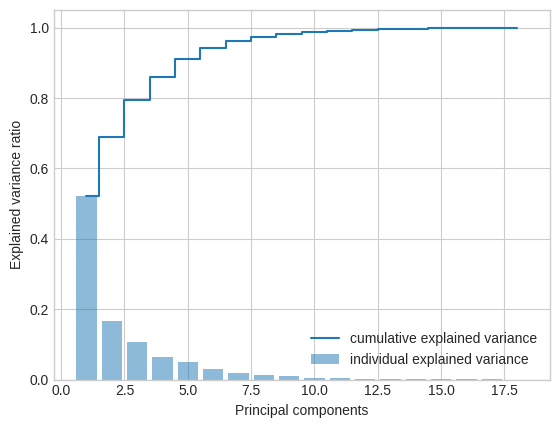

In [ ]:
plt.bar(range(1,19), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,19),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Dimensionality Reduction:  

In [ ]:
# P_reduce represents reduced mathematical space....

P_reduce_1 = np.array(eigvectors_sorted[0:8])   # Reducing from 8 to 4 dimension space

X_train_std_pca = np.dot(ssx_train_sd,P_reduce_1.T)   # projecting original data into principal component dimensions

X_test_std_pca = np.dot(ssx_test_sd,P_reduce_1.T)
#Proj_data_df_new = pd.DataFrame(X_std_8D_1)

print(X_train_std_pca)
print(X_test_std_pca)

Projected_df_train = pd.DataFrame(X_train_std_pca)
Projected_df_test = pd.DataFrame(X_test_std_pca)

[[ 0.42539526  1.24411116  0.0920144  ...  0.35280681  0.70841383
   0.44218076]
 [ 4.47598509 -0.24881759  0.0326908  ...  0.79484402  0.16797084
  -0.65708125]
 [-0.03475812 -0.78464008  0.52326313 ...  1.60303958  0.53237902
  -0.29773397]
 ...
 [ 3.19073615  1.23268157 -1.0869036  ...  0.19793032 -0.82639657
   0.04142069]
 [-0.62642778 -0.88841797  0.03849351 ...  0.49721736  0.19146008
   0.43186611]
 [-2.14280459 -2.17974938 -0.32947205 ...  0.7920075   0.66576056
   0.19032099]]
[[ 1.6075142   2.66026953 -0.08642128 ...  1.19071713 -0.0980658
  -0.5307237 ]
 [ 1.72281592  1.12267718 -0.0349234  ...  0.14069968  0.15360788
   0.33981102]
 [ 4.83287417 -1.30779067 -0.55807814 ...  1.94117498 -0.88921732
   0.20959758]
 ...
 [-1.91289259  2.74418055  0.35300766 ...  0.86254096  0.41848194
  -0.61104108]
 [ 4.44191766 -0.3888293  -0.49973128 ...  0.3938995  -0.12023314
  -0.52707814]
 [ 1.39032753  1.1423302   0.09292355 ... -0.42066853 -0.50573381
   0.86688687]]


### Pairplot Analysis : On Training PCA Data Set

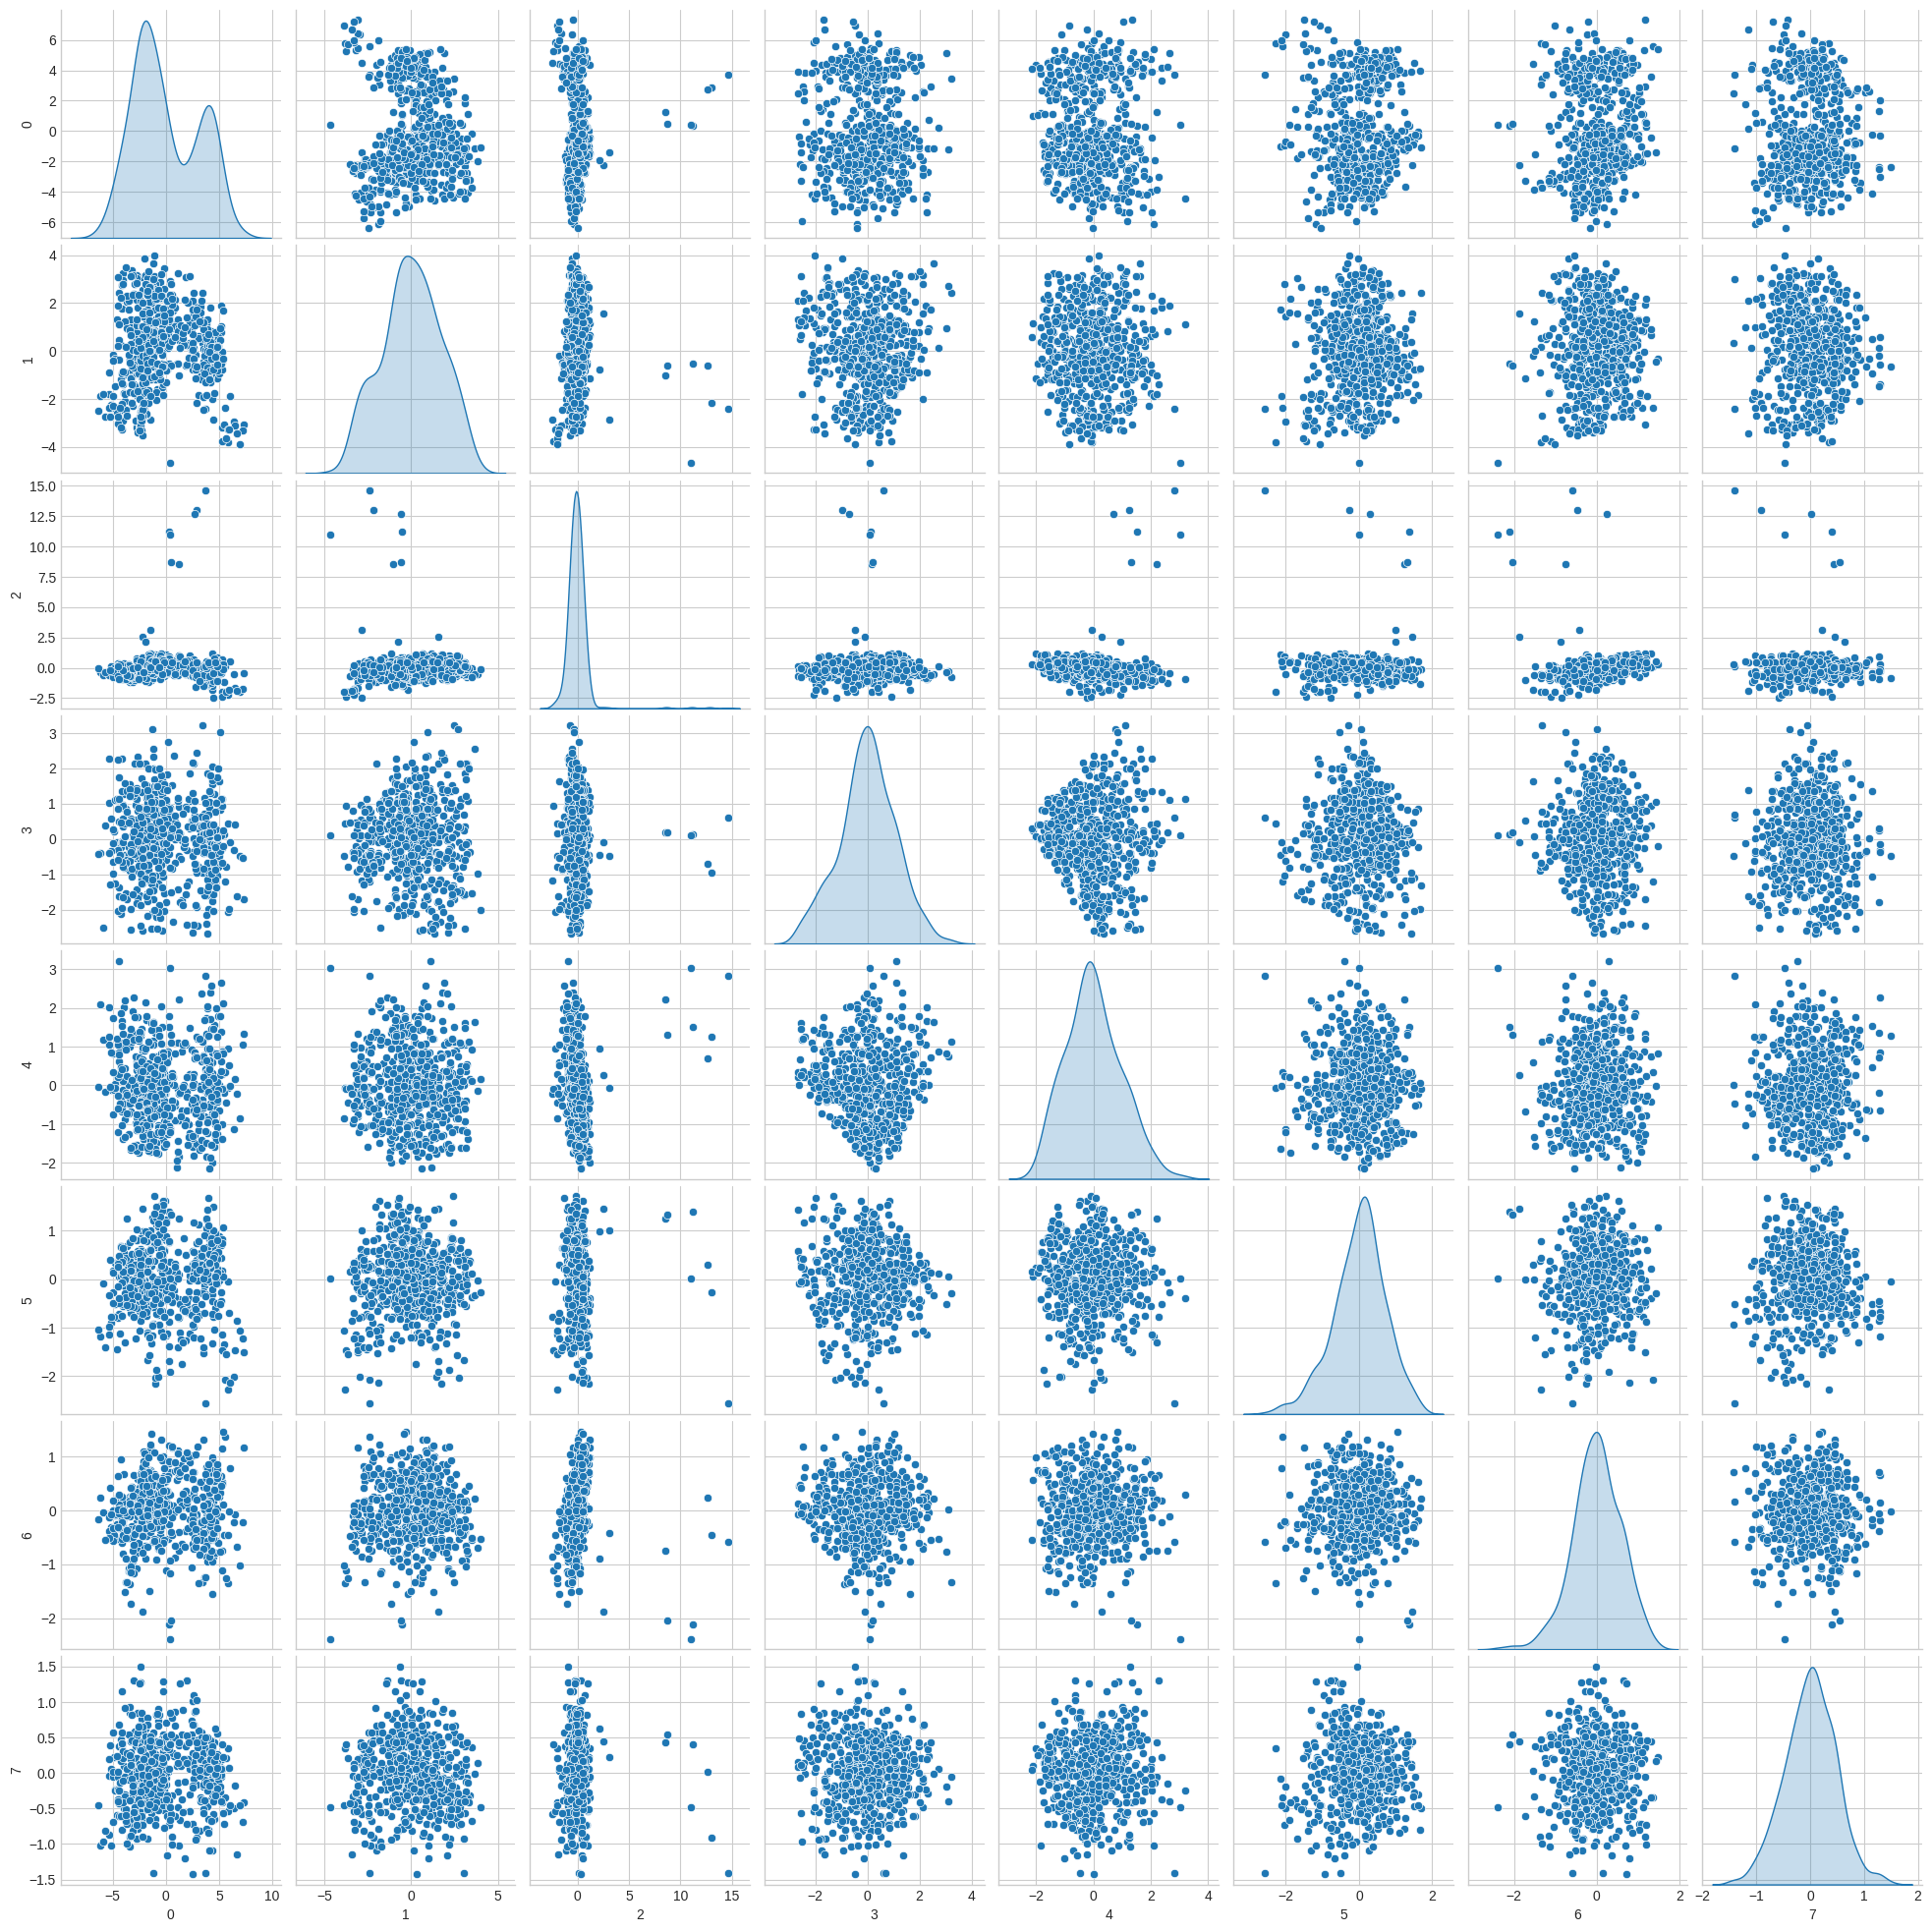

In [ ]:
sns.pairplot(Projected_df_train, diag_kind='kde')


In [ ]:
### Pairplot Analysis : On Test PCA Data Set

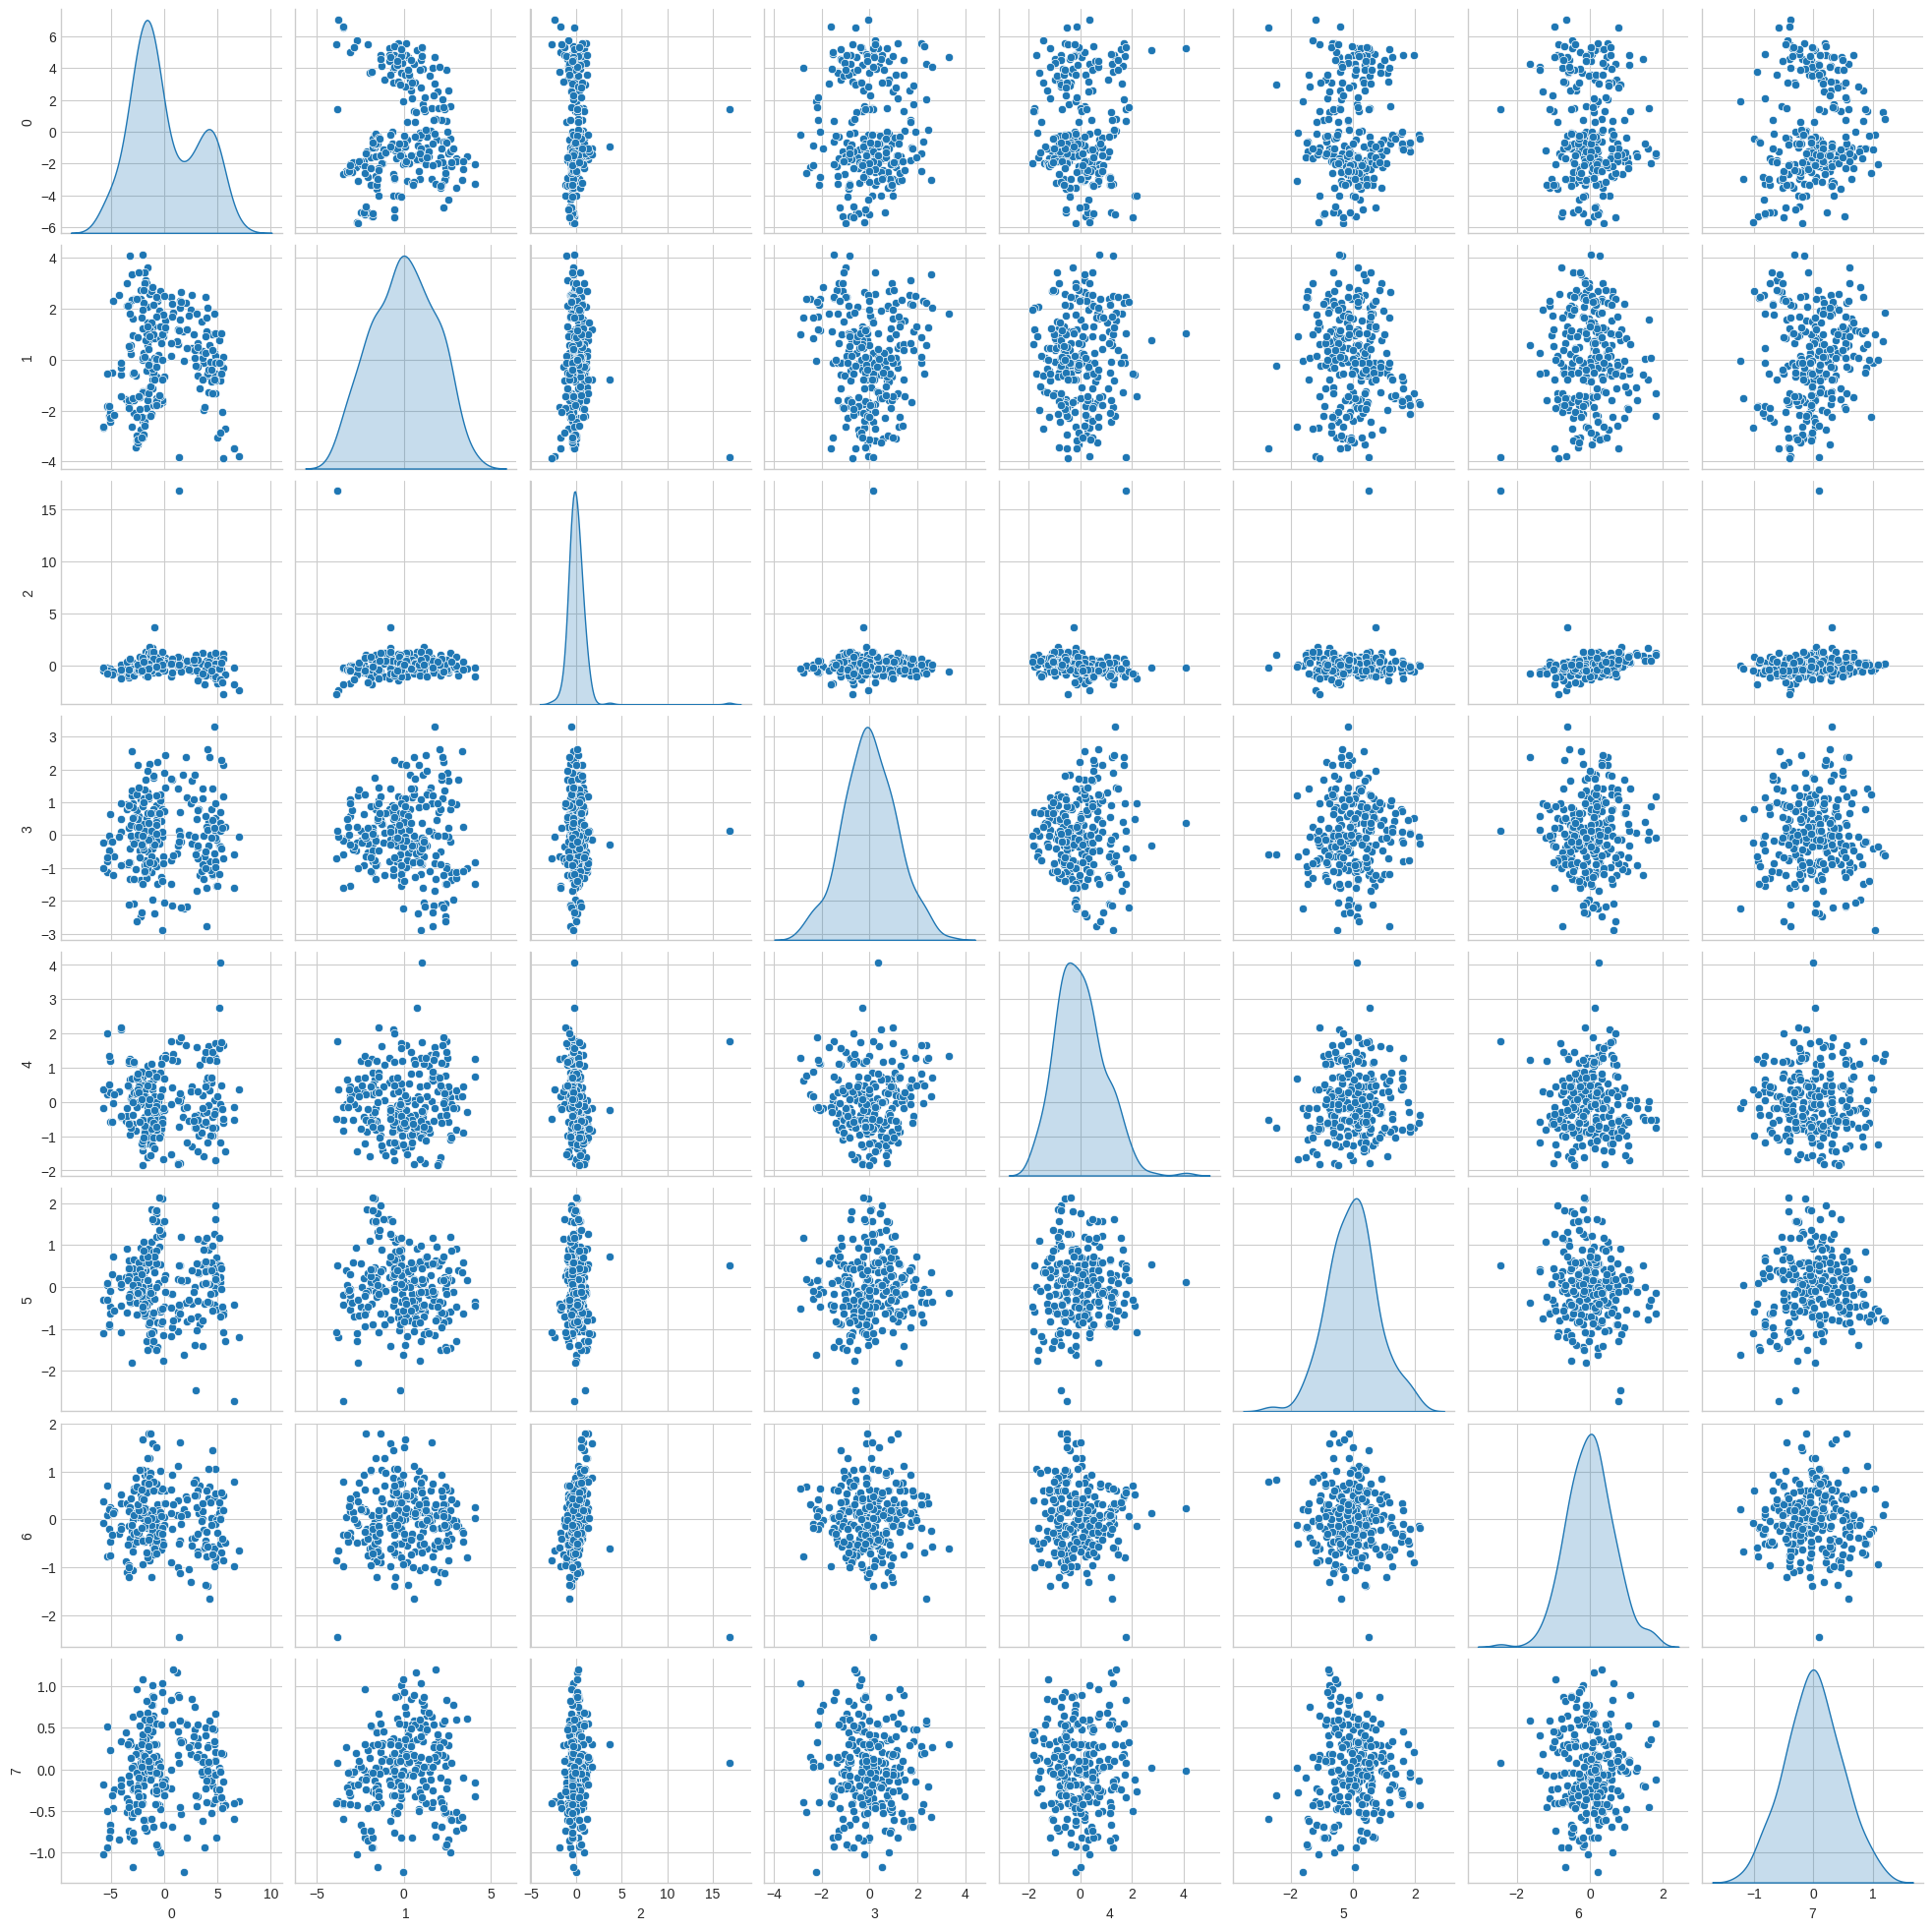

In [ ]:
sns.pairplot(Projected_df_test, diag_kind='kde')

### Quick Insights:

    - We can see that after we performed PCA our new dataframe with reduced dimesnions has no to zero linear relationship among themseleves, which is the main objective of using PCA tool. Almost all attribures have cloud of data in the mathematical space with no clear positive or negative correlation.
    

In [ ]:
ssx_train_sd.shape, P_reduce_1.T.shape, X_train_std_pca.shape, X_test_std_pca.shape

((592, 18), (18, 8), (592, 8), (254, 8))

In [ ]:
clf1 = SVC()
clf1.fit(ssx_train_sd, SplitScale_y_train)
print ('Before PCA score', clf1.score(ssx_test_sd, SplitScale_y_test))

clf2 = SVC()
clf2.fit(X_train_std_pca, SplitScale_y_train)
print ('After PCA score', clf2.score(X_test_std_pca, SplitScale_y_test))


#print("Before PCA On Original 18 Dimension",accuracy_score(Orig_y_test,Orig_y_predict))
#print("After PCA(On 8 dimension)",accuracy_score(pca_y_test,pca_y_predict))

#predict the y value
pca_yhat_predict= clf2.predict(X_test_std_pca)

#orginal data yhat value
orig_yhat_predict = clf1.predict(ssx_test_sd)

print("Before PCA On Original 18 Dimension",accuracy_score(SplitScale_y_test,orig_yhat_predict))
print("After PCA(On 8 dimension)",accuracy_score(SplitScale_y_test,pca_yhat_predict))

Before PCA score 0.9566929133858267
After PCA score 0.9409448818897638
Before PCA On Original 18 Dimension 0.9566929133858267
After PCA(On 8 dimension) 0.9409448818897638


### Quick Observation: After we split the data set into test & train set before applying standardscaler():

   - On training data set we saw that our support vector classifier without performing PCA has an accuracy score of 95 %
   - But when we applied the SVC model on PCA componenets(reduced dimensions) our model still performed better with 95 % with only miniscule fall in score.
   - So earlier when we scaled the data first and then use it to build our model we saw a 1-2 % difference in accuracy score of svc model build on orignal & pca data set respectively. But when we changed our strategy by splitting the data set into train-test first and then using it scale the train & test data set we avoided the possible data leakage, which resulted in very minor change in accuracy score, when model was built both on original data set & pca data set.
   
   - Considering that original dataframe had 18 dimensions and After PCA dimension reduced to 8, our model has fared well in terms of accuracy score.

# Calculate Confusion Matrix & Plot To Visualize it

Confusion Matrix For: 
 Original Data Set 
 [[ 68   1   2]
 [  1 118   6]
 [  0   1  57]]


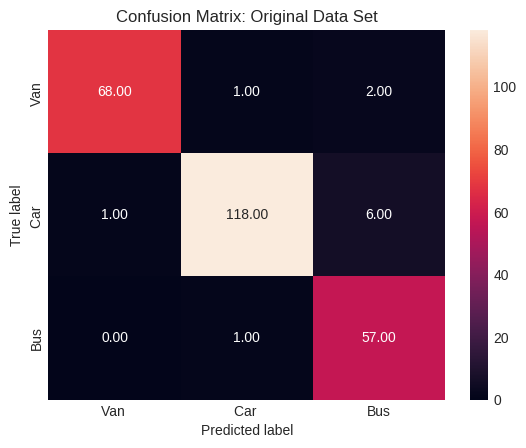

Confusion Matrix For: 
 For Reduced Dimensions Using PCA  
 [[ 66   2   3]
 [  2 118   5]
 [  0   3  55]]


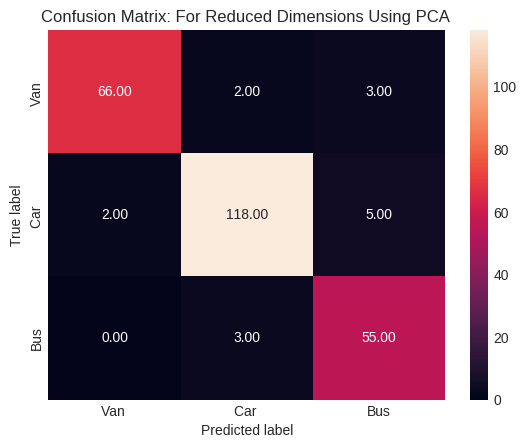

Classification Report For Raw Data: 
               precision    recall  f1-score   support

         0.0       0.99      0.96      0.97        71
         1.0       0.98      0.94      0.96       125
         2.0       0.88      0.98      0.93        58

    accuracy                           0.96       254
   macro avg       0.95      0.96      0.95       254
weighted avg       0.96      0.96      0.96       254

Classification Report For PCA: 
               precision    recall  f1-score   support

         0.0       0.97      0.93      0.95        71
         1.0       0.96      0.94      0.95       125
         2.0       0.87      0.95      0.91        58

    accuracy                           0.94       254
   macro avg       0.93      0.94      0.94       254
weighted avg       0.94      0.94      0.94       254



In [ ]:

draw_confmatrix(SplitScale_y_test, orig_yhat_predict,"Van ", "Car ", "Bus", "Original Data Set" )

draw_confmatrix(SplitScale_y_test, pca_yhat_predict,"Van ", "Car ", "Bus", "For Reduced Dimensions Using PCA ")

#Classification Report Of Model built on Raw Data
print("Classification Report For Raw Data:", "\n", classification_report(SplitScale_y_test,orig_yhat_predict))

#Classification Report Of Model built on Principal Components:

print("Classification Report For PCA:","\n", classification_report(SplitScale_y_test,pca_yhat_predict))

## Quick Insights On Confusion Matrix:
         
     - In our approach 1: we saw that our model actual instances of Van : 59, car : 133 and bus : 62   
     - But in our second approach where we split the data set and then scaled , we saw the actual categorization instances as Van : 71, Car : 125, Bus: 58
     
## Confusion Matrix For :

### Original Data Set:

 [[ 68   1   2]
 [  1 118   6]
 [  0   1  57]]
   
     and
     
 For Reduced Dimensions Using PCA
 [[ 68   3   0]
 [  2 118   5]
 [  1   1  56]]


- Clearly both the model has almost same level of precitiability when it comes to correctly classifying van , car and bus. Which was not the case with approach 1.

- IN approach one our confuson matrix showed that model on original data out of 133 actual car instance, correctly predicted 129 instances to be cars. while in appraich to out of actual 125 cars , it has correctly predicted 118 of instances to be a car .


## Let's Apply Grid Search & Cross-Validation:To Tune Our Model and Validate The Model's Accuracy Score

In [ ]:
import itertools

def classifiers_hypertune(name,rf,param_grid,x_train_scaled,y_train,x_test_scaled,y_test,CV):
    CV_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=CV, verbose= 1, n_jobs =-1 )
    CV_rf.fit(x_train_scaled, y_train)

    y_pred_train = CV_rf.predict(x_train_scaled)
    y_pred_test = CV_rf.predict(x_test_scaled)

    print('Best Score: ', CV_rf.best_score_)
    print('Best Params: ', CV_rf.best_params_)



    #Classification Report
    print(name+" Classification Report: ")
    print(classification_report(y_test, y_pred_test))


    #Confusion Matrix for test data
    draw_confmatrix(y_test, y_pred_test,"Van", "Car", "Bus", "Original Data Set" )
    print("SVM Accuracy Score:",round(accuracy_score(y_test, y_pred_test),2)*100)


In [ ]:

#Training on SVM Classifier
from sklearn.model_selection import GridSearchCV
svmc = SVC()

#Let's See What all parameters one can tweak
print("SVM Parameters:", svmc.get_params())

# Create the parameter grid based on the results of random search
param_grid = [
  {'C': [0.01, 0.05, 0.5, 1], 'kernel': ['linear']},
  {'C': [0.01, 0.05, 0.5, 1],  'kernel': ['rbf']},
 ]

param_grid_1 = [
  {'C': [1, 10, 100, 1000], 'kernel': ['linear']},
  {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
 ]

SVM Parameters: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


## Hypertuning SVM using hyper Parameters:

### Iteration 1:

### In Case Of PCA:


In [ ]:
import itertools

def classifiers_hypertune(name,rf,param_grid,x_train_scaled,y_train,x_test_scaled,y_test,CV):
    CV_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=CV, verbose= 1, n_jobs =-1, score_params=None) # Add score_params=None
    CV_rf.fit(x_train_scaled, y_train)

    y_pred_train = CV_rf.predict(x_train_scaled)
    y_pred_test = CV_rf.predict(x_test_scaled)

    print('Best Score: ', CV_rf.best_score_)
    print('Best Params: ', CV_rf.best_params_)



    #Classification Report
    print(name+" Classification Report: ")
    print(classification_report(y_test, y_pred_test))


    #Confusion Matrix for test data
    draw_confmatrix(y_test, y_pred_test,"Van", "Car", "Bus", "Original Data Set" )
    print("SVM Accuracy Score:",round(accuracy_score(y_test, y_pred_test),2)*100)

In [ ]:
classifiers_hypertune("Support Vector Classifier", svmc, param_grid,X_train_std_pca, SplitScale_y_train, X_test_std_pca, SplitScale_y_test,10)

TypeError: GridSearchCV.__init__() got an unexpected keyword argument 'score_params'

### Quick Insight:

### Hyper tuning of Model on PCA Data Set:

   - We generally tune some of the important hyperparameters of the model which are not the model parameter. like here we played with C value : penalty and the type of kernel : rbf/liner  
   
   - GridSearchCV get's the best paramter from the array of parameters and find the best model and score for us.
   - Here on perfroming gridsearch hyper tuning of SVM model we got the best parameter to  be
    : Best Score:  0.9256756756756757
    : Best Params:  {'C': 1, 'kernel': 'rbf'}
    : Accruacy Score : 95 % which seems to be similar to than what we measured earlier in our appraoch 2
    
    - We can further play with hyper parameters and see if it helps to score our model better.

### For Original Data Set:

In [ ]:
classifiers_hypertune("Support Vector Classifier", svmc, param_grid,ssx_train_sd, SplitScale_y_train, ssx_test_sd, SplitScale_y_test,10)


### On Orginal Data Set:

   - When we apploed GridSearchCV on Our model which is using orginal data set, we saw
      - Best Score:  0.956081081081081
      - Best Params:  {'C': 1, 'kernel': 'rbf'}
      - Accuracy Score : We saw an improvement in accuracy score to  96 % which is better than what we observed in approach 2 and approach 1


# Let's further tweak the parameters to see if we can improve our model accuracy :

In [ ]:
classifiers_hypertune("Support Vector Classifier_iterarion2", svmc, param_grid_1,X_train_std_pca, SplitScale_y_train, X_test_std_pca, SplitScale_y_test,10)

### Iteration 2 : On original Data Set

In [ ]:
classifiers_hypertune("Support Vector Classifier", svmc, param_grid_1,ssx_train_sd, SplitScale_y_train, ssx_test_sd, SplitScale_y_test,10)

### We can see a slight improvement in best model which was picked by our gridsearchcv method: 96.79 % and also we saw a slight increase in model accuracy score : 97 %

## Closing Comments:

    - So we can see that how Principal component analysis can help us cherry pick only the relevant features by analysing the relationship between independent attributes to see which one will be more helpful in building our model without introducing any impurity in it.
    
    - We can increase the models performance both in terms of processing speed and the ease of implementing it .
    
    - Also we learned that one should always make sure data is normalized/scaled before perfroming PCA, else the result will not be as per expectations
    - Also it is recommended though it's not a rule , to split your data set into test-train before you apply data normalization/scaling. This will help our model to perfrom more realistically in production environment.
    - If one scale the model before splitting it into train-test , there is a high chance of data leakage . By data leakage i mean that our model will be alaready influenced by test data , as it has tasted a bit of test data even before it will fit and tested on it.
    
    - Also once one have tried every bit of techniques of removing outliers, treating the missing value, normalizing  the data whenever required, applied the diffrent models to come up with better model based on metrics which suits more the problem statement. It is advisable to fine tune it using hyperparameter tuning techniques which tunes the model performances and also employs Cross-fold validation internally to make sure our model is ready to face production environment.
    
- It would be good if we also measure how other classifier model like logistic regression, decisiontree , emsemble model like randomforrestclassifier will perfrom both on original data & PCA data. It would be interesting to see the confusion matrix and various others metrics like recall score, precision score, f1-score etc.

- But Since our objective was to see how PCA data set impacts the model perfromance specially on training data set , we have here achived our objective and saw that PCA is great tool to make our model perfrom better .

## Let's Look How Some Other Classifier Models Perform Bith On Original Data & PCA treated data sets

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(ssx_train_sd, SplitScale_y_train)
print ('Before PCA score', model.score(ssx_test_sd, SplitScale_y_test))

model.fit(X_train_std_pca, SplitScale_y_train)
print ('After PCA score', model.score(X_test_std_pca, SplitScale_y_test))



### Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(ssx_train_sd, SplitScale_y_train)
print ('Before PCA score', nb.score(ssx_test_sd, SplitScale_y_test))

nb.fit(X_train_std_pca, SplitScale_y_train)
print ('After PCA score', nb.score(X_test_std_pca, SplitScale_y_test))


### Decisiontree Classifier:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion = 'entropy' )

dt_model.fit(ssx_train_sd, SplitScale_y_train)
print ('Before PCA score', dt_model.score(ssx_test_sd, SplitScale_y_test))

dt_model.fit(X_train_std_pca, SplitScale_y_train)
print ('After PCA score', dt_model.score(X_test_std_pca, SplitScale_y_test))


## It Seems that Support Vectore Classifier is a better model to classifiy the given silhoutte info as van, bus, car .

In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Get current time in IST
now_ist = datetime.now(ist)

# Format the date and time separately
formatted_date = now_ist.strftime('%Y-%m-%d')
formatted_time = now_ist.strftime('%H:%M:%S %Z%z')

# Print statement indicating this is the last cell and all above cells have been executed
print("All cells above have been executed. Below is the current date and time in IST:")

# Display the date in bold
display(Markdown(f'**Date: {formatted_date}**'))

# Display the time in bold
display(Markdown(f'**Time: {formatted_time}**'))


## Interview Preparation: Key Concepts and Findings from the Notebook

Here are some potential interview questions based on the notebook content and their answers:

### Q1: What was the main objective of this notebook?
**A1:** The main objective was to classify vehicles (bus, car, van) based on their silhouette features using dimensionality reduction with PCA and Support Vector Classifiers (SVC).

### Q2: What dataset was used and what are its characteristics?
**A2:** The `vehicle-2.csv` dataset was used. It contains features extracted from vehicle silhouettes. The dataset has 19 columns (18 features and 1 class) and 846 entries. It had some missing values and outliers.

### Q3: How were the missing values handled?
**A3:** Missing values were imputed using the median strategy with `sklearn.impute.SimpleImputer`.

### Q4: What was the approach for handling outliers?
**A4:** Outliers were identified using box plots and the Interquartile Range (IQR) method. Data points outside the range of Q1 - 1.5 * IQR and Q3 + 1.5 * IQR were removed.

### Q5: What was observed from the correlation analysis of the features?
**A5:** The correlation heatmap and pairplot revealed several highly correlated features (both positive and negative). This indicated multicollinearity, which can negatively impact model performance.

### Q6: Why was Principal Component Analysis (PCA) applied?
**A6:** PCA was applied to address the issue of multicollinearity and reduce the dimensionality of the dataset while retaining most of the important information. The goal was to create a smaller set of uncorrelated features (principal components).

### Q7: How was the number of principal components determined?
**A7:** The number of principal components was determined by analyzing the explained variance ratio. The plot of explained variance showed that 8 principal components could explain over 95% of the variance in the original data.

### Q8: What were the two approaches for applying PCA and training the model, and why was the second approach considered better?
**A8:**
1. **Approach 1:** Scale the entire dataset first, then split into train and test sets, and finally apply PCA and train the model.
2. **Approach 2:** Split the data into train and test sets first, then scale each set independently, and finally apply PCA and train the model.

Approach 2 is generally considered better because it prevents data leakage from the test set into the training process during scaling, leading to a more realistic evaluation of the model's performance in a production environment.

### Q9: How did the SVC model perform on the original data compared to the PCA-transformed data in both approaches?
**A9:**
*   **Approach 1:** The SVC model on original data had an accuracy of around 95%, while on PCA data it was around 93%. There was a slight drop in accuracy, but with significantly reduced dimensions.
*   **Approach 2:** The SVC model on original data and PCA data had very similar accuracy scores (around 95-94%). This demonstrated that with proper data splitting and scaling, PCA could reduce dimensionality with minimal impact on accuracy.

### Q10: How was hyperparameter tuning performed for the SVC model?
**A10:** GridSearchCV was used to tune the hyperparameters of the SVC model, specifically the `C` (regularization parameter) and `kernel` (linear or rbf). Cross-validation (with 10 folds) was used within GridSearchCV to find the best parameters and evaluate the model's performance.

### Q11: What was the impact of hyperparameter tuning on the model's accuracy?
**A11:** Hyperparameter tuning with GridSearchCV resulted in a slight improvement in the model's accuracy, reaching up to 97% on the original data in the second iteration of tuning.

### Q12: What other classification models were briefly explored, and how did their performance compare to SVC?
**A12:** Logistic Regression, Naive Bayes, and Decision Tree Classifier were also briefly explored. Based on the initial scores, the Support Vector Classifier appeared to be a better model for this classification task compared to these other models.

### Q13: What are the key takeaways from this notebook regarding PCA and model building?
**A13:**
*   PCA is a valuable tool for dimensionality reduction and addressing multicollinearity.
*   It can improve model processing speed and ease of implementation.
*   Data should always be scaled/normalized before applying PCA.
*   Splitting data into train/test sets *before* scaling is crucial to prevent data leakage and ensure a more realistic model evaluation.
*   Hyperparameter tuning and cross-validation are important steps to optimize model performance and ensure its readiness for production.

## Interview Preparation: Key Concepts and Real-World Applications

Here are some potential interview questions based on the notebook's purpose, predictions, and real-world applications of the concepts covered, presented as bulleted questions and answers:

*   **What is the main purpose of this notebook?**
    *   This notebook focuses on using machine learning techniques, specifically dimensionality reduction with Principal Component Analysis (PCA) and classification with Support Vector Classifiers (SVC), to classify vehicles (bus, car, or van) based on their silhouette features. It also explores data preprocessing steps like handling missing values and outliers, and model evaluation techniques like confusion matrices and hyperparameter tuning.

*   **What does the model in this notebook predict?**
    *   The model predicts the class of a vehicle silhouette, classifying it as either a 'bus', 'car', or 'van'.

*   **What are some sample use cases for this type of classification?**
    *   **Automated Vehicle Identification:** Systems that automatically identify vehicle types for traffic monitoring, surveillance, or toll collection.
    *   **Manufacturing Quality Control:** Inspecting the shape of manufactured parts to ensure they meet specifications.
    *   **Security and Surveillance:** Identifying different types of objects or vehicles in security footage.
    *   **Autonomous Driving:** Helping self-driving cars recognize and differentiate between various types of vehicles on the road.

*   **What are some real-world services or products that use the concepts demonstrated in this notebook (PCA, SVC for classification)?**
    *   **Image Recognition Software:** Many image recognition and computer vision applications use dimensionality reduction techniques like PCA and classification algorithms like SVM (which SVC is a type of) for tasks like facial recognition, object detection, and image categorization.
    *   **Spam Detection Filters:** SVCs can be used to classify emails as spam or not spam based on various features.
    *   **Medical Diagnosis:** Classifying medical images or patient data to diagnose diseases.
    *   **Financial Fraud Detection:** Identifying fraudulent transactions by classifying patterns in financial data.
    *   **Recommendation Systems:** While more complex models are often used, the underlying principles of classifying items based on features can be applied in recommendation engines.
    *   **Netflix and other streaming services:** These services use classification and other ML techniques to categorize content and recommend shows/movies to users.
    *   **E-commerce Platforms:** Classifying products, identifying fraudulent reviews, and personalizing user experience.

*   **Why is dimensionality reduction like PCA important in machine learning?**
    *   **Reduces Training Time:** Fewer features mean less data for the model to process.
    *   **Combats the Curse of Dimensionality:** Helps in dealing with datasets that have a very large number of features, which can lead to sparsity and make it difficult for models to find patterns.
    *   **Removes Multicollinearity:** PCA creates uncorrelated principal components, which can improve the performance and interpretability of some models.
    *   **Reduces Memory Requirements:** Storing fewer features requires less memory.
    *   **Helps with Visualization:** Reducing data to 2 or 3 dimensions allows for easier plotting and understanding of the data's structure.

*   **What is a Support Vector Classifier (SVC) and when is it useful?**
    *   SVC is a powerful supervised machine learning algorithm used for classification. It works by finding the optimal hyperplane that best separates different classes in the feature space. SVC is particularly useful for:
        *   **High-dimensional data:** It performs well in datasets with many features.
        *   **Cases with clear margin of separation:** It is effective when there is a distinct boundary between classes.
        *   **Non-linear data:** Using different kernels (like the radial basis function - rbf) allows SVC to handle non-linearly separable data.

*   **Why is it important to split data into training and testing sets BEFORE scaling or applying PCA?**
    *   Splitting data before scaling or PCA prevents data leakage. If scaling or PCA is applied to the entire dataset before splitting, information from the test set "leaks" into the training process through the calculation of scaling parameters (like mean and standard deviation) or PCA components. This can lead to overly optimistic performance estimates on the test set and poor generalization to new, unseen data in a real-world scenario.

*   **What is the purpose of hyperparameter tuning and cross-validation?**
    *   **Hyperparameter Tuning:** The process of finding the best set of hyperparameters for a model that result in the best performance on a given dataset. Hyperparameters are parameters that are not learned from the data but are set before training (e.g., the `C` and `kernel` in SVC).
    *   **Cross-Validation:** A technique used to evaluate a model's performance and assess how well it will generalize to unseen data. It involves splitting the data into multiple folds and training/testing the model on different combinations of these folds. This provides a more robust estimate of performance compared to a single train-test split and helps in selecting the best model and hyperparameters.

*   **Based on the notebook, how did PCA impact the SVC model's performance?**
    *   When PCA was applied correctly (after splitting the data), the SVC model on the reduced 8 dimensions achieved a very similar accuracy score to the model trained on the original 18 dimensions. This demonstrates that PCA successfully reduced the dimensionality without significant loss of predictive power, potentially leading to a more efficient model.

*   **What are the key takeaways from this notebook for building machine learning models?**
    *   Data preprocessing (handling missing values and outliers) is crucial.
    *   Dimensionality reduction techniques like PCA can be effective for dealing with high-dimensional and multicollinear data.
    *   The order of data splitting, scaling, and PCA is important to avoid data leakage.
    *   Hyperparameter tuning and cross-validation are essential for optimizing model performance and ensuring good generalization.
    *   Evaluating models using various metrics (accuracy, confusion matrix, classification report) provides a comprehensive understanding of their performance.